# Agent 1 — Analyste de crise virale X/Twitter

**Projet : Datathon “Gérer une crise virale avec des agents IA”**  
**Cas : Ultia × CNC**  
**Objectif Jour 2 : construire le premier agent IA opérationnel.**

Ce notebook crée l'**Agent 1 : Analyste de crise**.  
Son rôle : prendre le corpus X/Twitter, détecter les pics, résumer la dynamique, identifier les comptes moteurs, les narratifs dominants et produire un brief clair pour la cellule de communication de crise.

Ce notebook est prévu pour **Kaggle avec GPU T4×2**.  
Le GPU est utilisé surtout pour la partie **LLM local** optionnelle qui transforme les chiffres en brief rédigé.  
L'analyse des données avec Pandas reste principalement CPU, ce qui est normal.

## Ce que produit l'agent

- KPIs globaux du corpus.
- Timeline journalière et horaire.
- Détection automatique des pics.
- Analyse d'une période/pic choisi.
- Top auteurs, top hashtags, top posts.
- Narratifs dominants par règles de mots-clés.
- Crisis Velocity Score et niveau de risque.
- Rapport Markdown exporté.
- Graphiques exportés.
- Option LLM local sur GPU pour générer un brief professionnel.

## 0. À faire dans Kaggle avant de lancer

1. Créer un nouveau Notebook Kaggle.
2. Dans **Settings → Accelerator**, choisir **GPU T4 × 2**.
3. Ajouter le dataset contenant :
   - `data.xlsx`
   - `dictionnaire_bdd.xlsx`
4. Lancer toutes les cellules.

Le notebook cherche automatiquement les fichiers dans :

- `/kaggle/input/**/data*.xlsx`
- `/kaggle/input/**/dictionnaire*.xlsx`
- `/mnt/data/` si vous testez hors Kaggle.

In [1]:
# ============================================================
# 1. Imports et configuration générale
# ============================================================

import os
import re
import json
import math
import warnings
import unicodedata
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 220)

# Dossiers de sortie Kaggle
WORKDIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("/mnt/data")
OUTDIR = WORKDIR / "agent1_outputs"
FIGDIR = OUTDIR / "figures"
OUTDIR.mkdir(parents=True, exist_ok=True)
FIGDIR.mkdir(parents=True, exist_ok=True)

print("Dossier de sortie :", OUTDIR)

Dossier de sortie : /kaggle/working/agent1_outputs


In [2]:
# ============================================================
# 1 bis. Vérification lecture Excel
# ============================================================
# openpyxl sert à lire les fichiers .xlsx avec pandas.
# Si Kaggle ne l'a pas, cette cellule tente de l'installer.

try:
    import openpyxl
    print("openpyxl disponible:", openpyxl.__version__)
except Exception:
    import sys, subprocess
    print("openpyxl absent : installation...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "openpyxl"])
    import openpyxl
    print("openpyxl installé:", openpyxl.__version__)

openpyxl disponible: 3.1.5


In [3]:
# ============================================================
# 2. Vérification GPU Kaggle T4×2
# ============================================================

try:
    import torch
    HAS_TORCH = True
    print("PyTorch version:", torch.__version__)
    print("CUDA disponible:", torch.cuda.is_available())
    print("Nombre de GPU:", torch.cuda.device_count())
    if torch.cuda.is_available():
        for i in range(torch.cuda.device_count()):
            print(f"GPU {i}:", torch.cuda.get_device_name(i))
except Exception as e:
    HAS_TORCH = False
    print("PyTorch non disponible ou erreur:", e)

print("\nNote : Pandas lit/analyse les fichiers sur CPU. Le GPU sert surtout à la partie LLM local optionnelle.")

PyTorch version: 2.10.0+cu128
CUDA disponible: True
Nombre de GPU: 2
GPU 0: Tesla T4
GPU 1: Tesla T4

Note : Pandas lit/analyse les fichiers sur CPU. Le GPU sert surtout à la partie LLM local optionnelle.


In [4]:
# ============================================================
# 3. Recherche automatique des fichiers Excel
# ============================================================

# Si besoin, vous pouvez forcer les chemins ici :
DATA_PATH = None
DICT_PATH = None


def find_excel_file(kind="data"):
    '''Cherche automatiquement le fichier Excel dans Kaggle ou /mnt/data.'''
    search_roots = []
    if Path("/kaggle/input").exists():
        search_roots.append(Path("/kaggle/input"))
    if Path("/mnt/data").exists():
        search_roots.append(Path("/mnt/data"))
    
    patterns = []
    if kind == "data":
        patterns = ["data*.xlsx", "*data*.xlsx"]
    else:
        patterns = ["dictionnaire*.xlsx", "*dictionnaire*.xlsx", "*bdd*.xlsx"]
    
    candidates = []
    for root in search_roots:
        for pat in patterns:
            candidates.extend(list(root.rglob(pat)))
    
    # On évite de confondre dictionnaire et data
    if kind == "data":
        candidates = [p for p in candidates if "dictionnaire" not in p.name.lower() and "bdd" not in p.name.lower()]
    else:
        candidates = [p for p in candidates if "dictionnaire" in p.name.lower() or "bdd" in p.name.lower()]
    
    if not candidates:
        return None
    
    # Choix : le plus gros fichier est généralement data.xlsx
    candidates = sorted(set(candidates), key=lambda p: p.stat().st_size if p.exists() else 0, reverse=True)
    return candidates[0]

if DATA_PATH is None:
    DATA_PATH = find_excel_file("data")
if DICT_PATH is None:
    DICT_PATH = find_excel_file("dict")

print("DATA_PATH =", DATA_PATH)
print("DICT_PATH =", DICT_PATH)

if DATA_PATH is None:
    raise FileNotFoundError("Impossible de trouver data.xlsx. Ajoutez le fichier dans Kaggle Input ou renseignez DATA_PATH.")

DATA_PATH = /kaggle/input/datasets/lioneltchatchoua/agent1/data.xlsx
DICT_PATH = /kaggle/input/datasets/lioneltchatchoua/agent1/dictionnaire_bdd.xlsx


In [5]:
# ============================================================
# 4. Chargement du corpus et du dictionnaire
# ============================================================

# openpyxl est nécessaire pour lire les xlsx avec pandas.
# Sur Kaggle il est souvent déjà installé.

raw_df = pd.read_excel(DATA_PATH)
print("Shape corpus:", raw_df.shape)
display(raw_df.head(3))

if DICT_PATH is not None:
    dict_df = pd.read_excel(DICT_PATH)
    print("\nDictionnaire chargé:", dict_df.shape)
    display(dict_df.head(10))
else:
    dict_df = None
    print("Aucun dictionnaire trouvé. On continue avec la détection automatique des colonnes.")

Shape corpus: (35396, 30)


,Date,Url,Domain,Sentiment,Language,Country,City Code,Author,City,Expanded URLs,Likes,Comments,Shares,Full Text,Gender,Impressions,Mentioned Authors,X Author ID,X Followers,X Following,X Reply to,X Repost of,X Posts,X Verified,Reach,Engagement Type,Hashtags,postID,postDate,message_normalizer
0,2026-05-01 21:43:00.0,http://twitter.com/Chaumont_Loire/statuses/2050330168393093550,twitter.com,neutral,fr,France,NaN,Chaumont_Loire,NaN,https://www.cnc.fr/cinema/actualites/le-jardin-fait-son-cinema--au-festival-international-des-jardins-de-chaumontsurloire_2582239,2,0,0,« Le jardin fait son cinéma » au Festival International des Jardins de Chaumont-sur-Loire | CNC - https://t.co/ux8CeQdbl3 #GoogleAlerts,unknown,79,NaN,256065413,5858,2600,NaN,NaN,9211,False,3434,NaN,#googlealerts,1,2026-05-01,« le jardin fait son cinema » au festival international des jardins de chaumont sur loire | cnc https : / / t . co / ux8ceqdbl3 # googlealerts
1,2026-05-01 21:38:40.0,http://twitter.com/GuzmanStephane/statuses/2050329079019168114,twitter.com,neutral,fr,France,NaN,GuzmanStephane,NaN,https://x.com/FrDesouche/status/2050142007771709749/video/1,0,0,0,"RT @destinationcine Le clip ""Storm"" de Romain Gavras, fils de Costa Gavras, contient un passage insultant envers la France\nClip subventionné par le CNC et produit par la société de Jean Duhamel, fils de Nathalie Sai...",male,0,@destinationcine,472078811,1632,3203,NaN,http://twitter.com/destinationcine/statuses/2050294841318257137,348374,False,851,RETWEET,NaN,2,2026-05-01,"rt @ destinationcine le clip "" storm "" de romain gavras , fils de costa gavras , contient un passage insultant envers la franceclip subventionne par le cnc et produit par la societe de jean duhamel , fils de nathalie..."
2,2026-05-01 21:37:39.0,http://twitter.com/Lancelo34643571/statuses/2050328823216934990,twitter.com,neutral,fr,France,NaN,Lancelo34643571,NaN,https://x.com/JPatrierLeitus/status/2049899199735451697,0,0,0,"RT @FrDesouche La chorégraphie est formidable, mais pourquoi le CNC doit-il financer le clip d’un rappeur suédois richissime?\nhttps://t.co/zq6dRYi74U",male,0,@frdesouche,1473606857717694466,3169,3741,NaN,http://twitter.com/FrDesouche/statuses/2050109211221123487,126326,False,2039,RETWEET,NaN,3,2026-05-01,"rt @ frdesouche la choregraphie est formidable , mais pourquoi le cnc doit il financer le clip d un rappeur suedois richissime ? https : / / t . co / zq6dryi74u"



Dictionnaire chargé: (30, 2)


,nom de la colonne,explication
0,Date,Date type YYYY-MM-DD HH:MM:SS
1,Url,Url complet du post Twitter
2,Domain,Nom de la source ici seulement twitter.com
3,Sentiment,Le sentiment global exprimé dans le message
4,Language,Langue dominante du message
5,Country,Pays d'émission du message
6,City Code,Région d'émission du message (dépendant du déclaratif de l'auteur du message)
7,Author,Auteur du message (pseudo Twitter)
8,City,Ville d'émission du message (dépendant du déclaratif de l'auteur du message)
9,Expanded URLs,Urls partagés dans le contenu du message


In [6]:
# ============================================================
# 5. Normalisation des noms de colonnes et mapping automatique
# ============================================================


def strip_accents(s):
    if pd.isna(s):
        return ""
    return "".join(c for c in unicodedata.normalize("NFKD", str(s)) if not unicodedata.combining(c))


def norm_name(s):
    s = strip_accents(str(s)).lower().strip()
    s = re.sub(r"[^a-z0-9]+", "_", s)
    return s.strip("_")

# On garde les noms originaux mais on prépare un accès robuste
original_columns = list(raw_df.columns)
normalized_to_original = {norm_name(c): c for c in original_columns}

print("Colonnes détectées:")
for c in original_columns:
    print("-", c)


def find_col(possible_names, required=False):
    '''Trouve une colonne à partir de plusieurs noms possibles.'''
    for name in possible_names:
        key = norm_name(name)
        if key in normalized_to_original:
            return normalized_to_original[key]
    
    # recherche fuzzy simple
    possible_keys = [norm_name(x) for x in possible_names]
    for key, original in normalized_to_original.items():
        if any(pk in key or key in pk for pk in possible_keys):
            return original
    
    if required:
        raise KeyError(f"Colonne obligatoire introuvable parmi : {possible_names}")
    return None

COL = {
    "date": find_col(["Date", "datetime", "created_at", "post date", "postDate"], required=True),
    "url": find_col(["Url", "URL"]),
    "sentiment": find_col(["Sentiment"]),
    "language": find_col(["Language", "langue"]),
    "country": find_col(["Country", "pays"]),
    "author": find_col(["Author", "auteur", "username", "screen_name"], required=True),
    "likes": find_col(["Likes", "like_count"]),
    "comments": find_col(["Comments", "Replies", "reply_count"]),
    "shares": find_col(["Shares", "Retweets", "retweet_count"]),
    "text": find_col(["Full Text", "Text", "Tweet", "message", "content"], required=True),
    "text_norm": find_col(["message_normalizer", "message normalizer", "normalized_text", "texte_normalise"]),
    "impressions": find_col(["Impressions"]),
    "mentions": find_col(["Mentioned Authors", "mentions"]),
    "followers": find_col(["X Followers", "followers"]),
    "following": find_col(["X Following", "following"]),
    "reply_to": find_col(["X Reply to", "reply_to"]),
    "repost_of": find_col(["X Repost of", "repost_of", "retweeted_status"]),
    "x_posts": find_col(["X Posts", "statuses_count"]),
    "verified": find_col(["X Verified", "verified"]),
    "reach": find_col(["Reach"]),
    "engagement_type": find_col(["Engagement Type", "type"]),
    "hashtags": find_col(["Hashtags", "hashtags"]),
    "post_id": find_col(["postID", "post_id", "id"]),
    "post_date": find_col(["postDate", "post_date"]),
}

print("\nMapping utilisé par l'agent:")
print(json.dumps(COL, indent=2, ensure_ascii=False))

Colonnes détectées:
- Date
- Url
- Domain
- Sentiment
- Language
- Country
- City Code
- Author
- City
- Expanded URLs
- Likes
- Comments
- Shares
- Full Text
- Gender
- Impressions
- Mentioned Authors
- X Author ID
- X Followers
- X Following
- X Reply to
- X Repost of
- X Posts
- X Verified
- Reach
- Engagement Type
- Hashtags
- postID
- postDate
- message_normalizer

Mapping utilisé par l'agent:
{
  "date": "Date",
  "url": "Url",
  "sentiment": "Sentiment",
  "language": "Language",
  "country": "Country",
  "author": "Author",
  "likes": "Likes",
  "comments": "Comments",
  "shares": "Shares",
  "text": "Full Text",
  "text_norm": "message_normalizer",
  "impressions": "Impressions",
  "mentions": "Mentioned Authors",
  "followers": "X Followers",
  "following": "X Following",
  "reply_to": "X Reply to",
  "repost_of": "X Repost of",
  "x_posts": "X Posts",
  "verified": "X Verified",
  "reach": "Reach",
  "engagement_type": "Engagement Type",
  "hashtags": "Hashtags",
  "post_id"

In [7]:
# ============================================================
# 6. Nettoyage et enrichissement du corpus
# ============================================================

df = raw_df.copy()

# Date
DATE_COL = COL["date"]
df["dt"] = pd.to_datetime(df[DATE_COL], errors="coerce")
df = df.dropna(subset=["dt"]).copy()
df["date"] = df["dt"].dt.date
df["day"] = df["dt"].dt.floor("D")
df["hour"] = df["dt"].dt.floor("H")
df["hour_of_day"] = df["dt"].dt.hour
df["week"] = df["dt"].dt.to_period("W").astype(str)

# Texte
TEXT_COL = COL["text"]
TEXT_NORM_COL = COL["text_norm"] if COL["text_norm"] else TEXT_COL
df["text_raw"] = df[TEXT_COL].fillna("").astype(str)
df["text_norm"] = df[TEXT_NORM_COL].fillna(df["text_raw"]).astype(str).map(lambda x: strip_accents(x).lower())

# Auteur
AUTHOR_COL = COL["author"]
df["author"] = df[AUTHOR_COL].fillna("unknown").astype(str).str.strip()

# Numériques
for new_col, src in {
    "likes": COL["likes"],
    "comments": COL["comments"],
    "shares": COL["shares"],
    "impressions": COL["impressions"],
    "reach": COL["reach"],
    "followers": COL["followers"],
    "following": COL["following"],
    "x_posts": COL["x_posts"],
}.items():
    if src:
        df[new_col] = pd.to_numeric(df[src], errors="coerce").fillna(0)
    else:
        df[new_col] = 0

df["engagement_total"] = df["likes"] + df["comments"] + df["shares"]

# Type engagement
if COL["engagement_type"]:
    df["engagement_type"] = df[COL["engagement_type"]].fillna("ORIGINAL").astype(str).str.upper().str.strip()
else:
    df["engagement_type"] = "ORIGINAL"

# Détection retweet/repost/réponse/citation robuste
if COL["repost_of"]:
    has_repost_of = df[COL["repost_of"]].notna()
else:
    has_repost_of = False

df["is_retweet"] = df["engagement_type"].str.contains("RETWEET|REPOST", regex=True, na=False) | has_repost_of | df["text_raw"].str.startswith("RT ")
df["is_reply"] = df["engagement_type"].str.contains("REPLY", regex=True, na=False)
df["is_quote"] = df["engagement_type"].str.contains("QUOTE|CITATION", regex=True, na=False)
df["is_original"] = ~(df["is_retweet"] | df["is_reply"] | df["is_quote"])

# Sentiment
if COL["sentiment"]:
    df["sentiment"] = df[COL["sentiment"]].fillna("unknown").astype(str).str.lower().str.strip()
else:
    df["sentiment"] = "unknown"

# Hashtags robustes
HASHTAG_COL = COL["hashtags"]

def extract_hashtags(row):
    tags = []
    if HASHTAG_COL and pd.notna(row.get(HASHTAG_COL, np.nan)):
        tags += re.findall(r"#\w+", str(row[HASHTAG_COL]).lower())
    tags += re.findall(r"#\w+", str(row["text_raw"]).lower())
    return sorted(set(tags))

df["hashtags_list"] = df.apply(extract_hashtags, axis=1)
df["hashtags_joined"] = df["hashtags_list"].apply(lambda x: " ".join(x))

# Mentions
MENTIONS_COL = COL["mentions"]
def extract_mentions(row):
    mentions = []
    if MENTIONS_COL and pd.notna(row.get(MENTIONS_COL, np.nan)):
        mentions += re.findall(r"@\w+", str(row[MENTIONS_COL]).lower())
    mentions += re.findall(r"@\w+", str(row["text_raw"]).lower())
    return sorted(set(mentions))

df["mentions_list"] = df.apply(extract_mentions, axis=1)

print("Corpus nettoyé:", df.shape)
print("Période:", df["dt"].min(), "→", df["dt"].max())
display(df[["dt", "author", "engagement_type", "sentiment", "likes", "comments", "shares", "reach", "text_raw"]].head(3))

Corpus nettoyé: (35396, 57)
Période: 2026-03-19 23:13:01 → 2026-05-01 21:43:00


,dt,author,engagement_type,sentiment,likes,comments,shares,reach,text_raw
0,2026-05-01 21:43:00,Chaumont_Loire,ORIGINAL,neutral,2,0,0,3434,« Le jardin fait son cinéma » au Festival International des Jardins de Chaumont-sur-Loire | CNC - https://t.co/ux8CeQdbl3 #GoogleAlerts
1,2026-05-01 21:38:40,GuzmanStephane,RETWEET,neutral,0,0,0,851,"RT @destinationcine Le clip ""Storm"" de Romain Gavras, fils de Costa Gavras, contient un passage insultant envers la France\nClip subventionné par le CNC et produit par la société de Jean Duhamel, fils de Nathalie Sai..."
2,2026-05-01 21:37:39,Lancelo34643571,RETWEET,neutral,0,0,0,2039,"RT @FrDesouche La chorégraphie est formidable, mais pourquoi le CNC doit-il financer le clip d’un rappeur suédois richissime?\nhttps://t.co/zq6dRYi74U"


In [8]:
# ============================================================
# 7. Narratifs de diagnostic pour l'Agent Analyste
# ============================================================
# Important : ceci n'est pas encore l'Agent 2 complet.
# Ici, on ajoute des tags rapides par mots-clés pour aider l'Agent 1 à résumer les pics.
# Version vectorisée : plus rapide que faire des regex ligne par ligne.

NARRATIVE_KEYWORDS = {
    "Argent public / subventions": [
        r"argent public", r"subvention", r"subventionne", r"subventionnee", r"subventions",
        r"impot", r"impots", r"taxe", r"taxes", r"racket fiscal", r"vache a lait",
        r"fonds", r"finance", r"financer", r"financement", r"3 m", r"3m", r"millions"
    ],
    "Copinage / favoritisme": [
        r"copinage", r"favoritisme", r"favoriser", r"favorisera", r"potes", r"amis", r"proches",
        r"commission", r"corruption", r"clientelisme", r"entre soi", r"detournement"
    ],
    "Critique institutionnelle CNC": [
        r"\bcnc\b", r"centre national", r"institution", r"commission d aide", r"ministere", r"culture"
    ],
    "Ultia / Twitch": [
        r"ultia", r"twitch", r"streameuse", r"stream", r"live", r"youtube", r"tiktok"
    ],
    "Censure / idéologie": [
        r"censure", r"extreme droite", r"extreme-droite", r"ideologie", r"politique", r"gauche", r"droite",
        r"discrimination", r"ecarter", r"ecartera"
    ],
    "Suspension du fonds": [
        r"suspend", r"suspension", r"supprime", r"suppression", r"arrete le fonds", r"met fin", r"fonds d aide"
    ],
    "Harcèlement / menaces": [
        r"harcelement", r"cyberharcelement", r"menace", r"menaces", r"insulte", r"haine", r"violence"
    ],
    "Relais média / actualité": [
        r"flash", r"alerte", r"info", r"journal", r"media", r"article", r"communique", r"breaking"
    ],
}

# Création de colonnes booléennes par narratif
narrative_flag_cols = []
for narrative, patterns in NARRATIVE_KEYWORDS.items():
    pattern = "|".join(f"(?:{p})" for p in patterns)
    col = "narr_" + norm_name(narrative)
    df[col] = df["text_norm"].str.contains(pattern, regex=True, case=False, na=False)
    narrative_flag_cols.append((narrative, col))

# Transformation des flags en liste de narratifs par message
def flags_to_narratives(row):
    tags = [narr for narr, col in narrative_flag_cols if bool(row[col])]
    return tags if tags else ["Autre / non classé"]

df["narratives"] = df.apply(flags_to_narratives, axis=1)
df["main_narrative"] = df["narratives"].apply(lambda x: x[0] if x else "Autre / non classé")

# Score de risque approximatif par message pour le diagnostic rapide
sensitive_tags = {"Copinage / favoritisme", "Argent public / subventions", "Censure / idéologie", "Harcèlement / menaces", "Suspension du fonds"}
REACH_P95 = df["reach"].quantile(0.95)

def message_risk(row):
    score = 1
    tags = set(row["narratives"])
    score += len(tags & sensitive_tags)
    if row["sentiment"] in ["negative", "negatif", "négatif"]:
        score += 1
    if row["is_retweet"]:
        score += 0.5
    if row["reach"] >= REACH_P95:
        score += 1
    return int(min(5, max(1, round(score))))

df["risk_level"] = df.apply(message_risk, axis=1)

# Table narratifs globale
narrative_rows = []
for tags in df["narratives"]:
    for t in tags:
        narrative_rows.append(t)

narratives_global = pd.Series(narrative_rows).value_counts().reset_index()
narratives_global.columns = ["narrative", "count"]
narratives_global["pct_messages"] = narratives_global["count"] / len(df) * 100

display(narratives_global)

,narrative,count,pct_messages
0,Critique institutionnelle CNC,33320,94.134931
1,Argent public / subventions,21429,60.540739
2,Ultia / Twitch,12350,34.890948
3,Censure / idéologie,12345,34.876822
4,Relais média / actualité,10264,28.997627
5,Copinage / favoritisme,10034,28.347836
6,Harcèlement / menaces,5171,14.608995
7,Suspension du fonds,3632,10.261046
8,Autre / non classé,166,0.468980


In [9]:
# ============================================================
# 8. Fonctions de calcul de l'Agent Analyste
# ============================================================


def pct(x, total):
    return 0 if total == 0 else 100 * x / total


def safe_sum(s):
    return float(pd.to_numeric(s, errors="coerce").fillna(0).sum())


def format_int(x):
    try:
        return f"{int(round(float(x))):,}".replace(",", " ")
    except Exception:
        return str(x)


def compute_kpis(data):
    total = len(data)
    if total == 0:
        return {}
    return {
        "messages": int(total),
        "auteurs_uniques": int(data["author"].nunique()),
        "debut": str(data["dt"].min()),
        "fin": str(data["dt"].max()),
        "retweets": int(data["is_retweet"].sum()),
        "retweets_pct": pct(data["is_retweet"].sum(), total),
        "originaux": int(data["is_original"].sum()),
        "originaux_pct": pct(data["is_original"].sum(), total),
        "reponses": int(data["is_reply"].sum()),
        "citations": int(data["is_quote"].sum()),
        "likes": safe_sum(data["likes"]),
        "comments": safe_sum(data["comments"]),
        "shares": safe_sum(data["shares"]),
        "impressions": safe_sum(data["impressions"]),
        "reach": safe_sum(data["reach"]),
        "engagement_total": safe_sum(data["engagement_total"]),
        "sentiment_negatif_pct": pct(data["sentiment"].isin(["negative", "negatif", "négatif"]).sum(), total),
        "risk_moyen": float(data["risk_level"].mean()),
        "risk_max": int(data["risk_level"].max()),
    }


def top_authors(data, n=10):
    agg = data.groupby("author").agg(
        messages=("author", "size"),
        retweets=("is_retweet", "sum"),
        likes=("likes", "sum"),
        shares=("shares", "sum"),
        reach=("reach", "sum"),
        impressions=("impressions", "sum"),
        followers=("followers", "max"),
        risk_mean=("risk_level", "mean"),
    ).reset_index()
    agg["influence_score"] = (
        np.log1p(agg["reach"]) * 0.35 +
        np.log1p(agg["shares"]) * 0.25 +
        np.log1p(agg["likes"]) * 0.20 +
        np.log1p(agg["messages"]) * 0.10 +
        np.log1p(agg["followers"]) * 0.10
    )
    return agg.sort_values(["influence_score", "reach", "shares"], ascending=False).head(n)


def top_hashtags(data, n=15):
    tags = []
    for lst in data["hashtags_list"]:
        tags.extend(lst)
    if not tags:
        return pd.DataFrame(columns=["hashtag", "count"])
    return pd.Series(tags).value_counts().head(n).reset_index().rename(columns={"index": "hashtag", 0: "count"})


def top_posts(data, n=10):
    cols = ["dt", "author", "engagement_type", "sentiment", "likes", "comments", "shares", "reach", "risk_level", "text_raw"]
    return data.sort_values(["engagement_total", "reach", "shares"], ascending=False)[cols].head(n)


def narratives_table(data):
    rows = []
    for tags in data["narratives"]:
        for t in tags:
            rows.append(t)
    if not rows:
        return pd.DataFrame(columns=["narrative", "count", "pct_messages"])
    tab = pd.Series(rows).value_counts().reset_index()
    tab.columns = ["narrative", "count"]
    tab["pct_messages"] = tab["count"] / len(data) * 100
    return tab


def sentiment_table(data):
    tab = data["sentiment"].value_counts(dropna=False).reset_index()
    tab.columns = ["sentiment", "count"]
    tab["pct"] = tab["count"] / len(data) * 100
    return tab


def engagement_type_table(data):
    tab = data["engagement_type"].fillna("ORIGINAL").value_counts().reset_index()
    tab.columns = ["type", "count"]
    tab["pct"] = tab["count"] / len(data) * 100
    return tab

In [10]:
# ============================================================
# 9. Détection automatique des pics et Crisis Velocity Score
# ============================================================


def build_daily_timeline(data):
    tl = data.groupby("day").agg(
        messages=("author", "size"),
        auteurs=("author", "nunique"),
        retweets=("is_retweet", "sum"),
        reach=("reach", "sum"),
        impressions=("impressions", "sum"),
        engagement=("engagement_total", "sum"),
        risk_mean=("risk_level", "mean"),
    ).reset_index().sort_values("day")
    tl["retweets_pct"] = np.where(tl["messages"] > 0, tl["retweets"] / tl["messages"] * 100, 0)
    tl["rolling_mean_3d"] = tl["messages"].rolling(3, min_periods=1).mean()
    tl["zscore"] = (tl["messages"] - tl["messages"].mean()) / (tl["messages"].std(ddof=0) + 1e-9)
    return tl


def build_hourly_timeline(data):
    tl = data.groupby("hour").agg(
        messages=("author", "size"),
        auteurs=("author", "nunique"),
        retweets=("is_retweet", "sum"),
        reach=("reach", "sum"),
        impressions=("impressions", "sum"),
        engagement=("engagement_total", "sum"),
        risk_mean=("risk_level", "mean"),
    ).reset_index().sort_values("hour")
    tl["retweets_pct"] = np.where(tl["messages"] > 0, tl["retweets"] / tl["messages"] * 100, 0)
    tl["rolling_mean_6h"] = tl["messages"].rolling(6, min_periods=1).mean()
    tl["zscore"] = (tl["messages"] - tl["messages"].mean()) / (tl["messages"].std(ddof=0) + 1e-9)
    return tl


daily_timeline = build_daily_timeline(df)
hourly_timeline = build_hourly_timeline(df)

# Détection pics : gros volume + z-score élevé
peaks_daily = daily_timeline.sort_values(["messages", "zscore"], ascending=False).head(10).copy()
peaks_hourly = hourly_timeline.sort_values(["messages", "zscore"], ascending=False).head(20).copy()


def crisis_velocity_score(period_data, reference_data=df):
    '''Score 0-100 : volume, vitesse, reach, négativité, risque et retweets.'''
    if len(period_data) == 0:
        return 0
    k = compute_kpis(period_data)
    ref_daily = build_daily_timeline(reference_data)
    period_hours = max(1, (period_data["dt"].max() - period_data["dt"].min()).total_seconds() / 3600)
    volume_per_hour = len(period_data) / period_hours
    ref_volume_per_hour = len(reference_data) / max(1, (reference_data["dt"].max() - reference_data["dt"].min()).total_seconds() / 3600)
    
    volume_component = min(30, 10 * math.log1p(volume_per_hour / (ref_volume_per_hour + 1e-9)))
    reach_component = min(20, 20 * (np.log1p(k["reach"]) / np.log1p(reference_data["reach"].sum() + 1)))
    negativity_component = min(15, k["sentiment_negatif_pct"] / 100 * 15)
    rt_component = min(15, k["retweets_pct"] / 100 * 15)
    risk_component = min(20, (k["risk_moyen"] / 5) * 20)
    return round(volume_component + reach_component + negativity_component + rt_component + risk_component, 1)

print("Top pics journaliers")
display(peaks_daily[["day", "messages", "auteurs", "retweets_pct", "reach", "engagement", "zscore", "risk_mean"]])

print("Top pics horaires")
display(peaks_hourly[["hour", "messages", "auteurs", "retweets_pct", "reach", "engagement", "zscore", "risk_mean"]].head(10))

Top pics journaliers


,day,messages,auteurs,retweets_pct,reach,engagement,zscore,risk_mean
8,2026-03-27,7303,2993,88.265097,12032921,59417,3.907257,3.080926
7,2026-03-26,6775,2825,81.948339,24749186,256961,3.589796,3.171365
10,2026-03-29,4932,2796,93.957826,6517830,30440,2.481691,3.542174
9,2026-03-28,3988,2254,88.615848,4942624,20372,1.914110,3.408475
11,2026-03-30,2012,1369,89.960239,3338262,16486,0.726038,3.289761
12,2026-03-31,1356,1027,91.961652,2264637,12096,0.331617,2.919617
13,2026-04-01,1158,878,91.623489,2746938,11978,0.212570,3.378238
20,2026-04-08,992,729,70.665323,4991368,31405,0.112762,3.294355
21,2026-04-09,803,588,66.251557,2036227,24005,-0.000875,2.875467
22,2026-04-10,709,605,78.984485,1470653,6327,-0.057392,3.040903


Top pics horaires


,hour,messages,auteurs,retweets_pct,reach,engagement,zscore,risk_mean
88,2026-03-26 16:00:00,751,512,79.893475,1964810,20823,7.632994,3.149134
87,2026-03-26 15:00:00,714,523,80.252101,1094920,7926,7.235880,3.331933
89,2026-03-26 17:00:00,709,419,84.062059,1756147,14979,7.182216,3.201693
92,2026-03-26 20:00:00,659,387,86.798179,633691,1815,6.645577,3.151745
91,2026-03-26 19:00:00,649,382,85.053929,1491384,14247,6.538249,3.161787
90,2026-03-26 18:00:00,617,372,84.440843,969971,11530,6.194800,3.056726
103,2026-03-27 07:00:00,550,342,88.545455,2300970,7255,5.475703,3.250909
104,2026-03-27 08:00:00,514,334,83.463035,914693,6386,5.089322,3.097276
102,2026-03-27 06:00:00,484,305,93.181818,560942,2733,4.767339,3.295455
93,2026-03-26 21:00:00,473,280,87.315011,499484,1676,4.649278,3.234672


Graphique sauvegardé: /kaggle/working/agent1_outputs/figures/01_timeline_journaliere.png


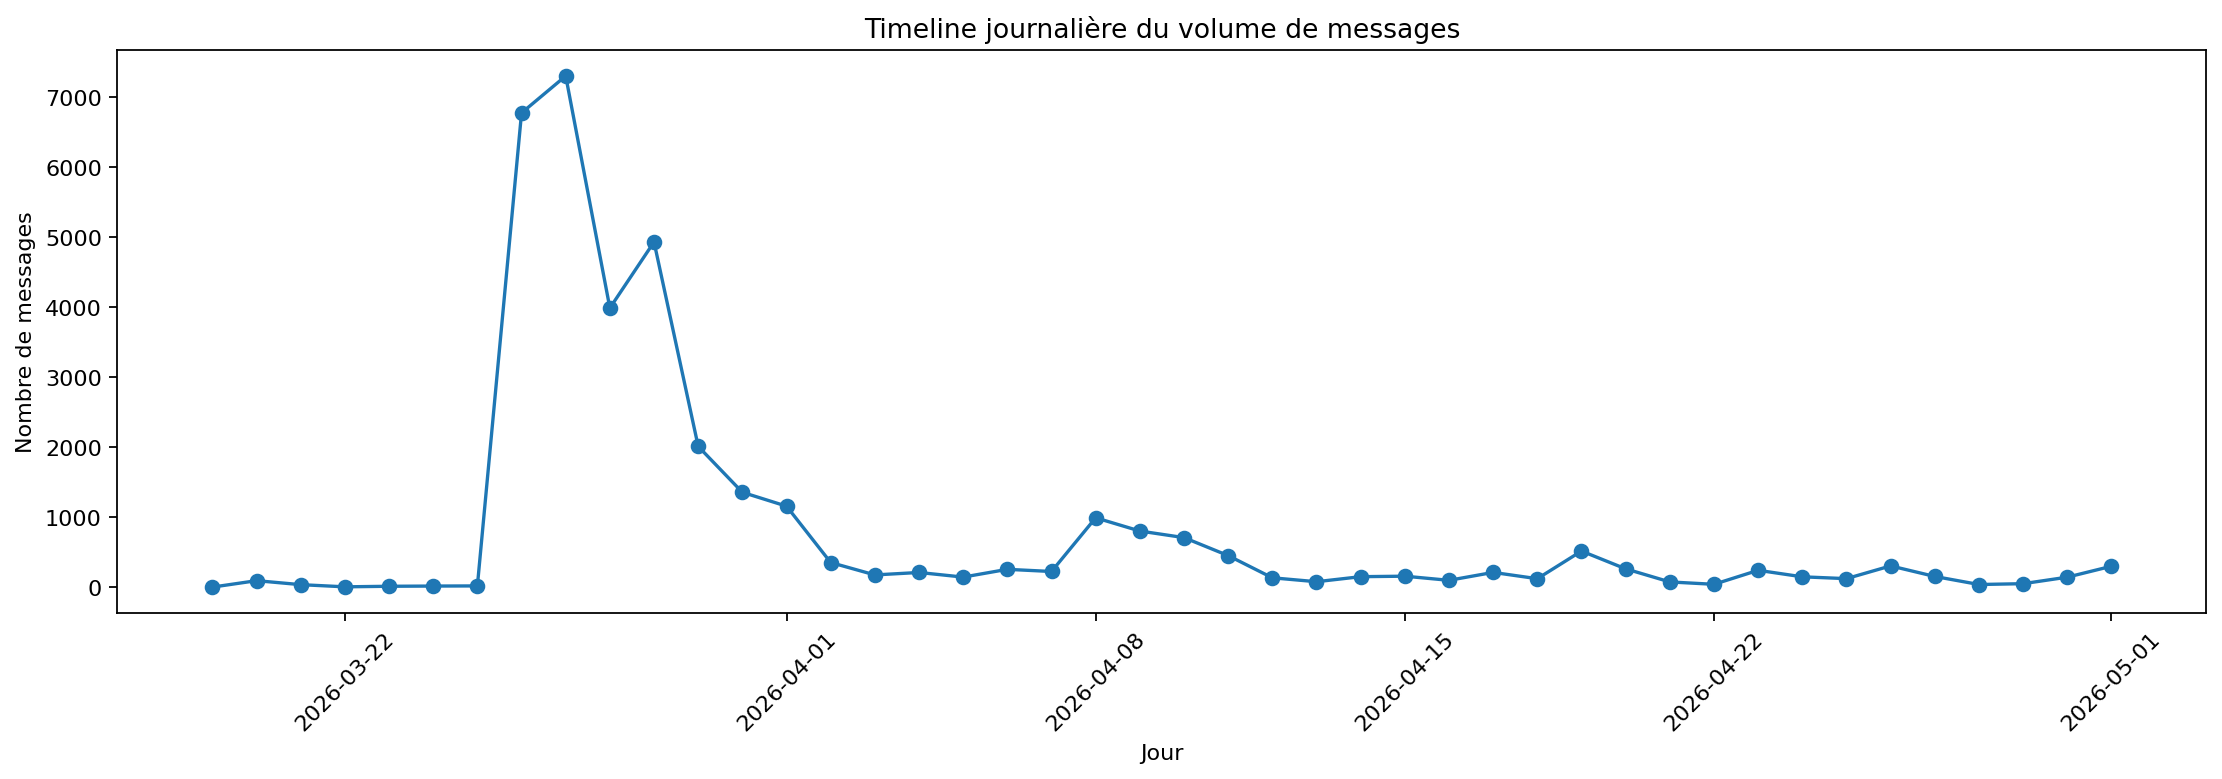

Graphique sauvegardé: /kaggle/working/agent1_outputs/figures/02_timeline_horaire_pics.png


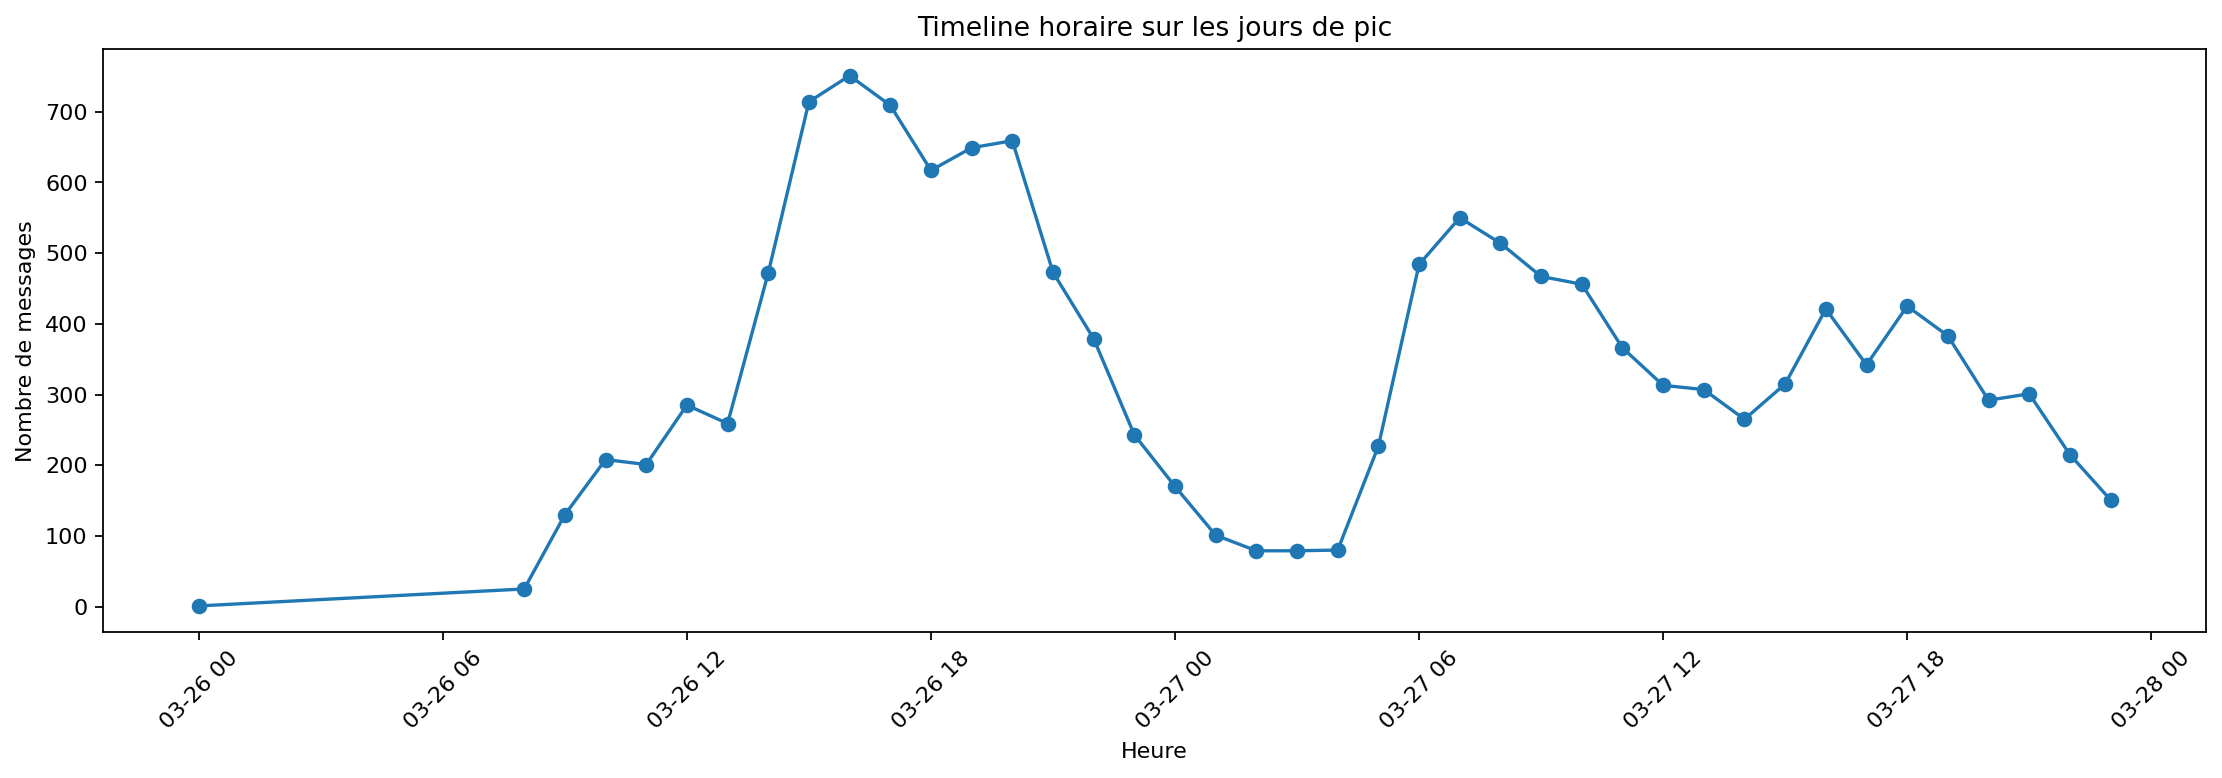

Graphique sauvegardé: /kaggle/working/agent1_outputs/figures/03_types_engagement.png


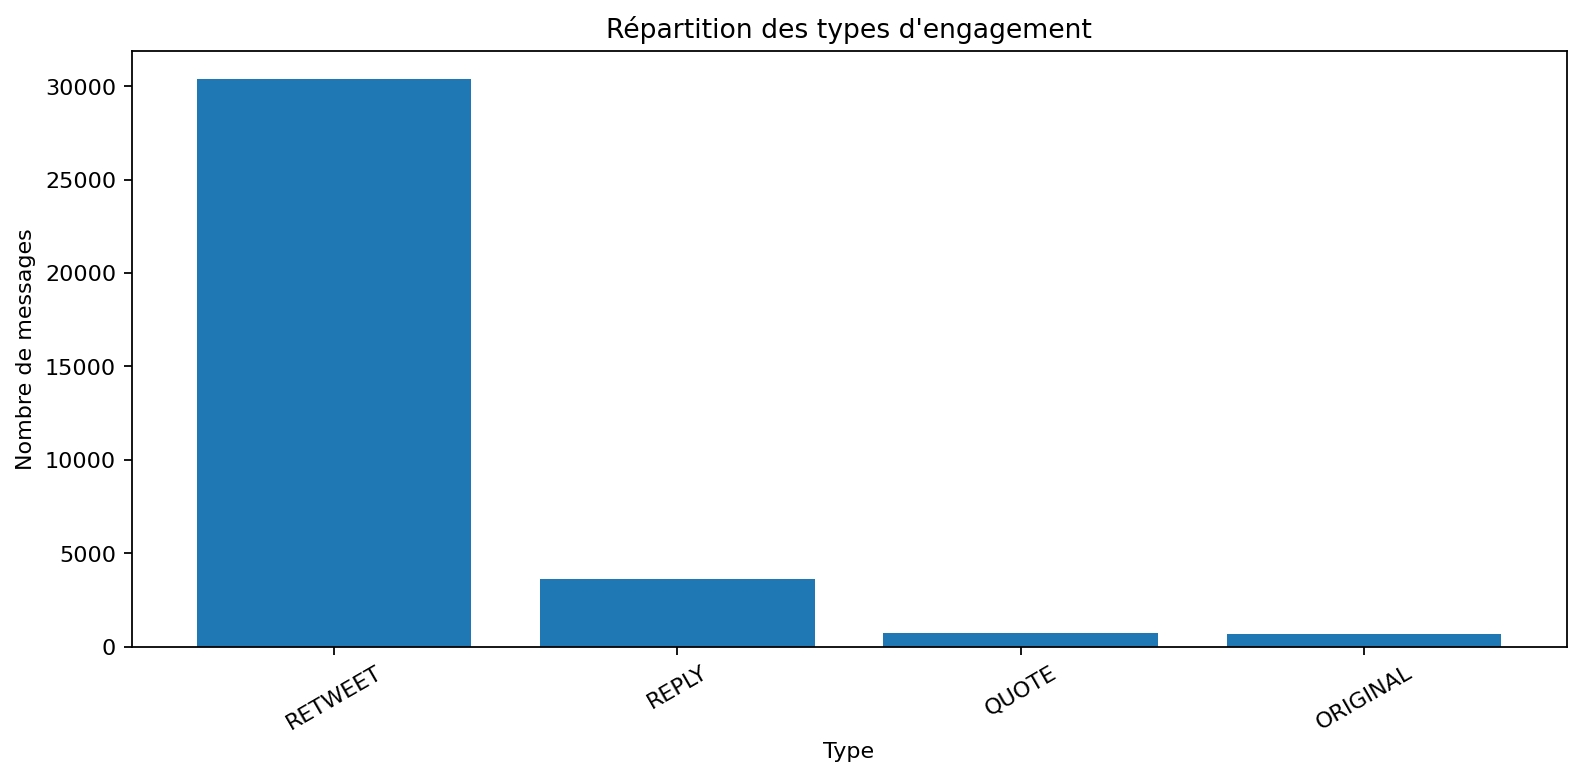

Graphique sauvegardé: /kaggle/working/agent1_outputs/figures/04_sentiment.png


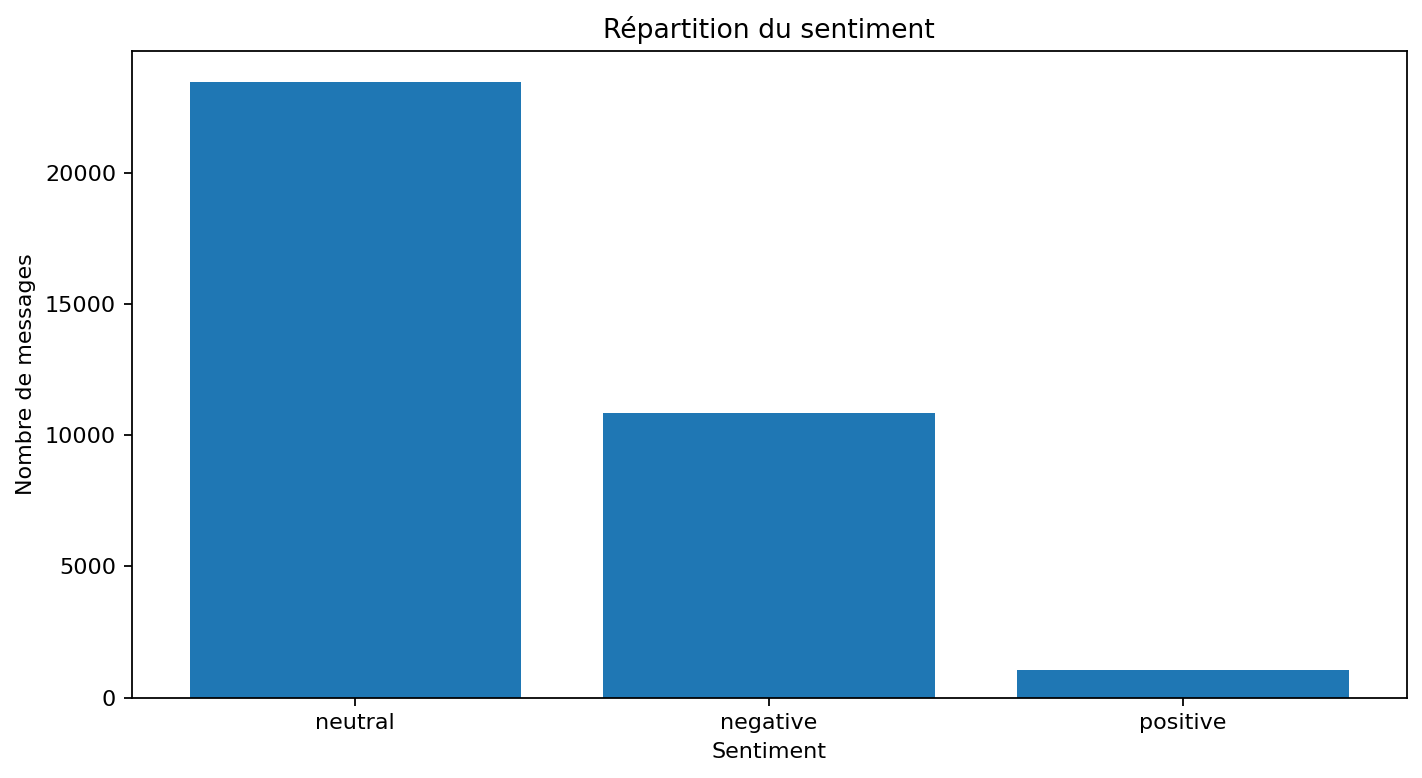

Graphique sauvegardé: /kaggle/working/agent1_outputs/figures/05_narratifs.png


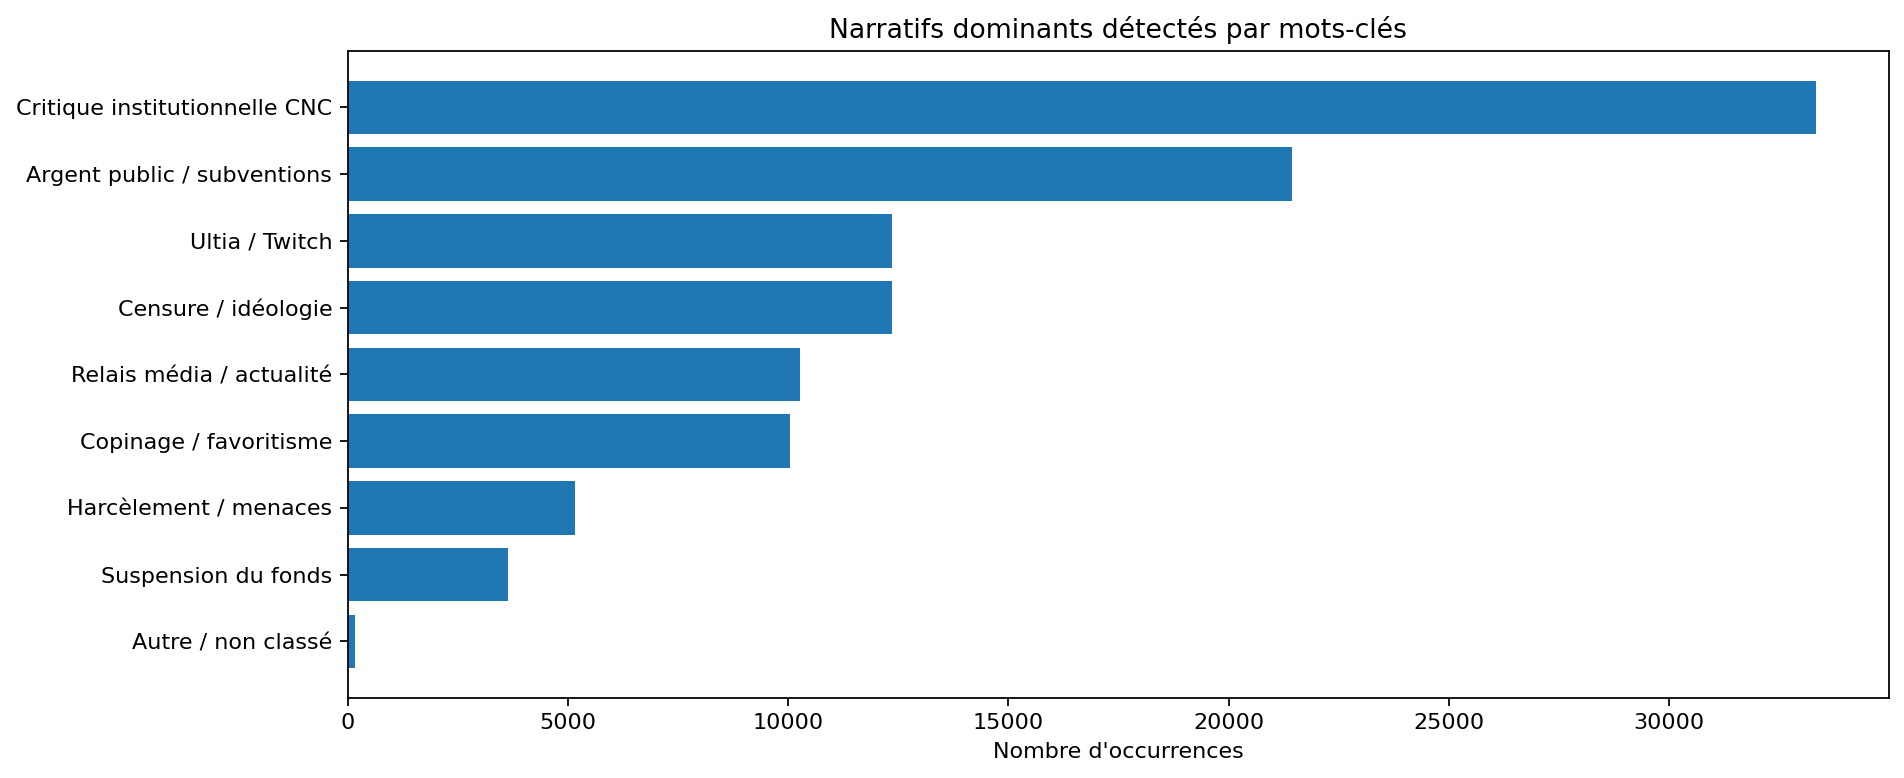

In [11]:
# ============================================================
# 10. Visualisations principales de l'Agent 1
# ============================================================


def save_fig(name):
    path = FIGDIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print("Graphique sauvegardé:", path)
    try:
        from IPython.display import Image, display
        display(Image(filename=str(path)))
    except Exception:
        pass
    plt.close()

# Timeline journalière
plt.figure(figsize=(14, 5))
plt.plot(daily_timeline["day"], daily_timeline["messages"], marker="o")
plt.title("Timeline journalière du volume de messages")
plt.xlabel("Jour")
plt.ylabel("Nombre de messages")
plt.xticks(rotation=45)
save_fig("01_timeline_journaliere.png")

# Timeline horaire des 2 meilleurs jours détectés
best_days = list(peaks_daily["day"].head(2))
focus = df[df["day"].isin(best_days)].copy()
focus_hourly = build_hourly_timeline(focus)
plt.figure(figsize=(14, 5))
plt.plot(focus_hourly["hour"], focus_hourly["messages"], marker="o")
plt.title("Timeline horaire sur les jours de pic")
plt.xlabel("Heure")
plt.ylabel("Nombre de messages")
plt.xticks(rotation=45)
save_fig("02_timeline_horaire_pics.png")

# Types d'engagement
eng_tab = engagement_type_table(df)
plt.figure(figsize=(10, 5))
plt.bar(eng_tab["type"], eng_tab["count"])
plt.title("Répartition des types d'engagement")
plt.xlabel("Type")
plt.ylabel("Nombre de messages")
plt.xticks(rotation=30)
save_fig("03_types_engagement.png")

# Sentiment
sent_tab = sentiment_table(df)
plt.figure(figsize=(9, 5))
plt.bar(sent_tab["sentiment"].astype(str), sent_tab["count"])
plt.title("Répartition du sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Nombre de messages")
save_fig("04_sentiment.png")

# Narratifs
narr_tab = narratives_table(df).head(10)
plt.figure(figsize=(12, 5))
plt.barh(narr_tab["narrative"][::-1], narr_tab["count"][::-1])
plt.title("Narratifs dominants détectés par mots-clés")
plt.xlabel("Nombre d'occurrences")
save_fig("05_narratifs.png")

In [12]:
# ============================================================
# 11. Agent 1 : classe AnalysteDeCrise
# ============================================================

class AnalysteDeCrise:
    '''
    Agent 1 du Datathon.
    Il analyse une période du corpus et produit un brief de crise basé sur des chiffres vérifiables.
    '''
    
    def __init__(self, data):
        self.df = data.copy()
        self.daily = build_daily_timeline(self.df)
        self.hourly = build_hourly_timeline(self.df)
    
    def filter_period(self, start=None, end=None):
        data = self.df.copy()
        if start is not None:
            start_dt = pd.to_datetime(start)
            data = data[data["dt"] >= start_dt]
        if end is not None:
            end_dt = pd.to_datetime(end)
            data = data[data["dt"] <= end_dt]
        return data.copy()
    
    def analyze_period(self, start=None, end=None, top_n=10):
        data = self.filter_period(start, end)
        if len(data) == 0:
            raise ValueError("Aucun message dans cette période.")
        
        result = {
            "periode": {"start": str(data["dt"].min()), "end": str(data["dt"].max())},
            "kpis": compute_kpis(data),
            "crisis_velocity_score": crisis_velocity_score(data, self.df),
            "top_authors": top_authors(data, n=top_n),
            "top_hashtags": top_hashtags(data, n=top_n),
            "top_posts": top_posts(data, n=top_n),
            "narratives": narratives_table(data),
            "sentiments": sentiment_table(data),
            "engagement_types": engagement_type_table(data),
            "hourly_timeline": build_hourly_timeline(data),
        }
        result["brief_deterministe"] = self.build_deterministic_brief(result)
        return result
    
    def analyze_peak_day(self, rank=1, top_n=10):
        peaks = self.daily.sort_values(["messages", "zscore"], ascending=False).reset_index(drop=True)
        day = peaks.loc[rank - 1, "day"]
        start = pd.to_datetime(day)
        end = start + pd.Timedelta(days=1) - pd.Timedelta(seconds=1)
        return self.analyze_period(start=start, end=end, top_n=top_n)
    
    def build_deterministic_brief(self, result):
        k = result["kpis"]
        score = result["crisis_velocity_score"]
        narr = result["narratives"].head(5)
        sent = result["sentiments"]
        top_a = result["top_authors"].head(5)
        
        dominant_narrative = narr.iloc[0]["narrative"] if len(narr) else "non identifié"
        dominant_sent = sent.iloc[0]["sentiment"] if len(sent) else "unknown"
        top_author = top_a.iloc[0]["author"] if len(top_a) else "non identifié"
        
        if score >= 80:
            level = "CRISE FORTE"
        elif score >= 60:
            level = "CRISE ÉLEVÉE"
        elif score >= 40:
            level = "CRISE MODÉRÉE"
        else:
            level = "SIGNAL FAIBLE / BRUIT"
        
        lines = []
        lines.append(f"## Brief Agent 1 — Analyste de crise")
        lines.append("")
        lines.append(f"**Période analysée :** {result['periode']['start']} → {result['periode']['end']}")
        lines.append(f"**Niveau estimé :** {level}")
        lines.append(f"**Crisis Velocity Score :** {score}/100")
        lines.append("")
        lines.append("### 1. Chiffres clés")
        lines.append(f"- {format_int(k['messages'])} messages publiés par {format_int(k['auteurs_uniques'])} auteurs uniques.")
        lines.append(f"- {k['retweets_pct']:.1f}% de retweets/reposts : la crise fonctionne surtout par amplification.")
        lines.append(f"- Reach cumulé estimé : {format_int(k['reach'])} ; impressions : {format_int(k['impressions'])}.")
        lines.append(f"- Sentiment négatif : {k['sentiment_negatif_pct']:.1f}% ; risque moyen : {k['risk_moyen']:.2f}/5.")
        lines.append("")
        lines.append("### 2. Narratif dominant")
        lines.append(f"- Narratif principal détecté : **{dominant_narrative}**.")
        for _, row in narr.iterrows():
            lines.append(f"- {row['narrative']} : {format_int(row['count'])} occurrences ({row['pct_messages']:.1f}% des messages).")
        lines.append("")
        lines.append("### 3. Acteurs et amplification")
        lines.append(f"- Compte le plus influent sur la période : **@{top_author}** selon le score d'influence calculé.")
        for _, row in top_a.iterrows():
            lines.append(f"- @{row['author']} : {format_int(row['messages'])} messages, reach {format_int(row['reach'])}, shares {format_int(row['shares'])}.")
        lines.append("")
        lines.append("### 4. Lecture stratégique")
        lines.append("- Le sujet doit être traité comme une **dynamique virale**, pas comme une simple vérification de fake news.")
        lines.append("- Le point à surveiller est la mutation du débat : personne impliquée → institution → argent public / légitimité du fonds.")
        lines.append("- La cellule de crise doit répondre sur les règles, la transparence et les faits, sans entrer dans un affrontement politique.")
        return "\n".join(lines)
    
    def display_result(self, result):
        from IPython.display import Markdown, display
        display(Markdown(result["brief_deterministe"]))
        print("\nTop narratifs")
        display(result["narratives"].head(10))
        print("\nTop auteurs")
        display(result["top_authors"].head(10))
        print("\nTop posts")
        display(result["top_posts"].head(10))
    
    def export_result(self, result, prefix="agent1_analyse"):
        # Rapport markdown
        report_path = OUTDIR / f"{prefix}_rapport.md"
        report_path.write_text(result["brief_deterministe"], encoding="utf-8")
        
        # Exports CSV
        result["top_authors"].to_csv(OUTDIR / f"{prefix}_top_authors.csv", index=False, encoding="utf-8-sig")
        result["top_hashtags"].to_csv(OUTDIR / f"{prefix}_top_hashtags.csv", index=False, encoding="utf-8-sig")
        result["top_posts"].to_csv(OUTDIR / f"{prefix}_top_posts.csv", index=False, encoding="utf-8-sig")
        result["narratives"].to_csv(OUTDIR / f"{prefix}_narratives.csv", index=False, encoding="utf-8-sig")
        result["hourly_timeline"].to_csv(OUTDIR / f"{prefix}_hourly_timeline.csv", index=False, encoding="utf-8-sig")
        
        print("Exports terminés dans:", OUTDIR)
        print("Rapport:", report_path)
        return report_path

agent1 = AnalysteDeCrise(df)
print("Agent 1 prêt.")

Agent 1 prêt.


In [13]:
# ============================================================
# 12. Démo Agent 1 — analyse automatique du plus gros pic journalier
# ============================================================

result_peak1 = agent1.analyze_peak_day(rank=1, top_n=10)
agent1.display_result(result_peak1)
agent1.export_result(result_peak1, prefix="agent1_pic_principal")

## Brief Agent 1 — Analyste de crise

**Période analysée :** 2026-03-27 00:00:01 → 2026-03-27 23:59:48
**Niveau estimé :** CRISE ÉLEVÉE
**Crisis Velocity Score :** 71.5/100

### 1. Chiffres clés
- 7 303 messages publiés par 2 993 auteurs uniques.
- 88.3% de retweets/reposts : la crise fonctionne surtout par amplification.
- Reach cumulé estimé : 12 032 921 ; impressions : 5 225 055.
- Sentiment négatif : 34.3% ; risque moyen : 3.08/5.

### 2. Narratif dominant
- Narratif principal détecté : **Critique institutionnelle CNC**.
- Critique institutionnelle CNC : 6 894 occurrences (94.4% des messages).
- Argent public / subventions : 3 809 occurrences (52.2% des messages).
- Ultia / Twitch : 3 249 occurrences (44.5% des messages).
- Censure / idéologie : 2 898 occurrences (39.7% des messages).
- Copinage / favoritisme : 2 076 occurrences (28.4% des messages).

### 3. Acteurs et amplification
- Compte le plus influent sur la période : **@ojim_france** selon le score d'influence calculé.
- @ojim_france : 5 messages, reach 937 401, shares 2 249.
- @TwitchGauchiste : 1 messages, reach 1 657 215, shares 256.
- @Rivenzi_ : 1 messages, reach 185 802, shares 130.
- @labar0nn3_ : 1 messages, reach 111 763, shares 389.
- @xj0nathan : 3 messages, reach 183 247, shares 138.

### 4. Lecture stratégique
- Le sujet doit être traité comme une **dynamique virale**, pas comme une simple vérification de fake news.
- Le point à surveiller est la mutation du débat : personne impliquée → institution → argent public / légitimité du fonds.
- La cellule de crise doit répondre sur les règles, la transparence et les faits, sans entrer dans un affrontement politique.


Top narratifs


,narrative,count,pct_messages
0,Critique institutionnelle CNC,6894,94.399562
1,Argent public / subventions,3809,52.156648
2,Ultia / Twitch,3249,44.488566
3,Censure / idéologie,2898,39.682322
4,Copinage / favoritisme,2076,28.426674
5,Relais média / actualité,1961,26.851979
6,Harcèlement / menaces,805,11.022867
7,Suspension du fonds,513,7.024510
8,Autre / non classé,9,0.123237



Top auteurs


,author,messages,retweets,likes,shares,reach,impressions,followers,risk_mean,influence_score
2658,ojim_france,5,2,7940,2249,937401,286156,35850,3.6,9.766323
1787,TwitchGauchiste,1,0,3449,256,1657215,2204437,31654,3.0,9.134302
1535,Rivenzi_,1,0,3163,130,185802,267451,122970,3.0,8.318358
2432,labar0nn3_,1,0,4015,389,111763,38978,23547,5.0,8.295590
2964,xj0nathan,3,0,3602,138,183247,553145,19419,3.0,8.239067
2491,libremax_off,1,0,3367,245,150555,93337,16953,3.0,8.216620
232,BeeFun__,2,0,4618,210,196082,414312,3237,3.0,8.208886
2457,leJDD,2,0,708,146,139820,12131,553438,5.0,8.139473
227,BastionMediaFR,1,0,955,303,119041,45758,68581,4.0,8.075233
2754,regelegorila,2,0,1224,77,220824,91416,96046,2.0,8.075231



Top posts


,dt,author,engagement_type,sentiment,likes,comments,shares,reach,risk_level,text_raw
24678,2026-03-27 12:36:03,ojim_france,ORIGINAL,neutral,4794,102,871,331879,3,"🚨Entre 2019 et 2025, CNC Talent a distribué 160 000 EUROS au streamer d'extrême gauche Jean Massiet à la tête de l'émission politique Backseat. https://t.co/zQqiNxOIpG"
25375,2026-03-27 10:35:47,BeeFun__,QUOTE,negative,4598,96,210,185600,3,"Au final…\n\nUltia ne s’excusera JAMAIS et n’avouera jamais avoir tort. Ce n’est clairement pas la première fois qu’elle réagit comme ça : des valises pleines, elle en traîne déjà avec elle.\n\nLe plus simple aurait ..."
26921,2026-03-27 07:32:34,TwitchGauchiste,ORIGINAL,neutral,3449,1131,256,1657215,3,"« Au pire mes propos étaient maladroits, mais de là à être destituée sans sommation, sans avoir la chance de parler ou de me défendre ? » \n\n« Probablement que je n'aurais pas dû dire extrême droite… J'aurais dû dir..."
22209,2026-03-27 19:38:36,labar0nn3_,ORIGINAL,negative,4015,17,389,111763,5,"Si je résume le délire du CNC, c’est juste une énième affaire de gens se disant anti-système financés par le … système. Bon. La gauche 2.0 quoi.. 😂"
23047,2026-03-27 17:33:02,ojim_france,ORIGINAL,neutral,2572,191,1157,511757,4,"🔴Le média d'extrême gauche Blast a reçu 1,8 MILLIONS d’euros d’aides à la presse en quatre ans ; il a également reçu des subventions du CNC Talent (notamment 80000 euros en 2022). https://t.co/yIXzY2N7xU"
24215,2026-03-27 14:05:05,xj0nathan,QUOTE,neutral,3598,88,138,165917,2,P'tain 30.000 balles pour lire des livres sur Twitch alors que moi j'ai lâché un gros billet pour mon projet Vlog Assassin's Creed en Grèce où je mélange anecdotes sur le jeu et l'Histoire. \n\nSi j'avais su j'aurais...
26489,2026-03-27 08:19:57,libremax_off,QUOTE,negative,3367,65,245,150555,3,"""J'ai demandé au CNC parce que je ne comprenais pas leur décision""\n\nN'importe qui de censé vit un truc comme ça serait mort de honte.\n\nMais elle, ne s'en rend même pas compte !\nL'absolue certitude d'être dans le..."
22960,2026-03-27 17:50:11,Rivenzi_,ORIGINAL,neutral,3163,98,130,185802,3,Je vous propose ma dernière vidéo qui (comme toutes les autres) n’est pas financée par le CNC.\n\nBisous ! \n\nLe lien en dessous 👇 https://t.co/5ptHxidNkk
27306,2026-03-27 06:50:00,Nicolasexaspere,ORIGINAL,negative,2169,50,215,118328,4,POV : tu payes ta place de cinoche 19 balles en maxi plein tarif 4k supplément solidarité aux personnes en recherche d'emploi pour enfin voir le dernier spiderman.\n\nTu te demandes pourquoi ca coûte aussi cher pour ...
23054,2026-03-27 17:31:54,VraiconAlpin,ORIGINAL,negative,1884,2,107,31954,3,"Quand j'étais petit et que je ne voulais pas finir mon assiette, ma maman me disait de penser à tous ces créateurs de contenus à qui le CNC n'avait accordé que 75% du montant qu'ils demandaient."


Exports terminés dans: /kaggle/working/agent1_outputs
Rapport: /kaggle/working/agent1_outputs/agent1_pic_principal_rapport.md


PosixPath('/kaggle/working/agent1_outputs/agent1_pic_principal_rapport.md')

In [14]:
# ============================================================
# 13. Démo ciblée — période du 26 au 27 mars 2026
# ============================================================
# Vous pouvez changer les dates en fonction du feedback de l'animateur.

result_26_27 = agent1.analyze_period(
    start="2026-03-26 00:00:00",
    end="2026-03-27 23:59:59",
    top_n=10,
)
agent1.display_result(result_26_27)
agent1.export_result(result_26_27, prefix="agent1_26_27_mars")

## Brief Agent 1 — Analyste de crise

**Période analysée :** 2026-03-26 00:16:32 → 2026-03-27 23:59:48
**Niveau estimé :** CRISE ÉLEVÉE
**Crisis Velocity Score :** 71.8/100

### 1. Chiffres clés
- 14 078 messages publiés par 4 792 auteurs uniques.
- 85.2% de retweets/reposts : la crise fonctionne surtout par amplification.
- Reach cumulé estimé : 36 782 107 ; impressions : 37 704 952.
- Sentiment négatif : 31.3% ; risque moyen : 3.12/5.

### 2. Narratif dominant
- Narratif principal détecté : **Critique institutionnelle CNC**.
- Critique institutionnelle CNC : 12 853 occurrences (91.3% des messages).
- Argent public / subventions : 7 610 occurrences (54.1% des messages).
- Ultia / Twitch : 6 715 occurrences (47.7% des messages).
- Censure / idéologie : 5 461 occurrences (38.8% des messages).
- Copinage / favoritisme : 4 412 occurrences (31.3% des messages).

### 3. Acteurs et amplification
- Compte le plus influent sur la période : **@SirenesFR** selon le score d'influence calculé.
- @SirenesFR : 7 messages, reach 2 593 256, shares 3 388.
- @TwitchGauchiste : 4 messages, reach 4 073 896, shares 2 104.
- @LeCNC : 2 messages, reach 2 909 506, shares 1 737.
- @Sardoche_Lol : 11 messages, reach 1 120 345, shares 1 369.
- @ojim_france : 6 messages, reach 1 459 006, shares 3 743.

### 4. Lecture stratégique
- Le sujet doit être traité comme une **dynamique virale**, pas comme une simple vérification de fake news.
- Le point à surveiller est la mutation du débat : personne impliquée → institution → argent public / légitimité du fonds.
- La cellule de crise doit répondre sur les règles, la transparence et les faits, sans entrer dans un affrontement politique.


Top narratifs


,narrative,count,pct_messages
0,Critique institutionnelle CNC,12853,91.298480
1,Argent public / subventions,7610,54.055974
2,Ultia / Twitch,6715,47.698537
3,Censure / idéologie,5461,38.791021
4,Copinage / favoritisme,4412,31.339679
5,Relais média / actualité,3917,27.823554
6,Suspension du fonds,1809,12.849837
7,Harcèlement / menaces,1331,9.454468
8,Autre / non classé,20,0.142066



Top auteurs


,author,messages,retweets,likes,shares,reach,impressions,followers,risk_mean,influence_score
2610,SirenesFR,7,0,23837,3388,2593256,7384408,105790,4.142857,10.581695
2859,TwitchGauchiste,4,0,17057,2104,4073896,11243267,31654,3.750000,10.386140
1601,LeCNC,2,0,19504,1737,2909506,5172617,90748,3.500000,10.301477
2557,Sardoche_Lol,11,5,15778,1369,1120345,826508,610751,3.818182,10.194866
4257,ojim_france,6,2,11684,3743,1459006,717598,35850,3.833333,10.141137
547,CerfiaFR,1,0,11829,967,967287,1389301,1285098,5.000000,9.894224
1911,MenuManga,6,0,16229,1127,716732,922235,129261,3.000000,9.786385
245,Arno_Kikoo,30,1,7972,957,1312224,1623449,5322,2.900000,9.644885
1608,LeDindonFiscal,15,3,9193,2542,942171,644603,1749,2.866667,9.624112
2945,VraiconAlpin,9,1,14036,1425,479537,231696,21910,3.333333,9.533483



Top posts


,dt,author,engagement_type,sentiment,likes,comments,shares,reach,risk_level,text_raw
34057,2026-03-26 14:08:46,LeCNC,ORIGINAL,neutral,19503,1768,1735,2855797,5,"Le CNC a pris connaissance des déclarations publiques de la streameuse Ultia, nouvellement nommée membre de la commission du fonds d’aide à la création pour les plateformes sociales (sans y avoir encore siégé), relat..."
35185,2026-03-26 08:54:56,Sardoche_Lol,QUOTE,neutral,13505,276,1330,691254,5,Résumons :\n\nÀ partir du centre-droit\n- Cancel \n- Zero sponsor\n- Se font refuser tous les financements verrouillés par la gauche\n\nÀ gauche \n- Camp du bien\n- Sponsors\n- Se financent entre potes via le CNC\n\n...
33674,2026-03-26 14:55:43,CerfiaFR,ORIGINAL,neutral,11829,516,967,967287,5,"🇫🇷🎙️ FLASH | « Si t’es d’extrême droite, désolé, pas de thune. Si t’es mon pote, je te sauce le projet. » Après ces propos, dans lesquels elle reconnaît sa partialité, le CNC annonce avoir mis fin aux fonctions de la..."
28596,2026-03-26 23:19:21,libremax_off,ORIGINAL,negative,10132,81,1209,366236,4,"Le plus fou c'est pas qu'Ultia ait révélé que l'argent du CNC est distribué par copinage et gauchisme, ça on le savait déjà.\n\nLe plus fou c'est qu'elle l'ai dit comme si c'était normal. Que notre argent leur appart..."
35161,2026-03-26 09:17:29,MenuManga,QUOTE,negative,10199,114,827,349974,3,Coupez moi cette merde de CNC talent et rendez l'argent.
34022,2026-03-26 14:16:08,SirenesFR,QUOTE,neutral,9067,440,740,792201,5,"🔴 ALERTE INFO | LE CNC VIRE ULTIA SUITE À SES PROPOS AVOUANT SA PARTIALITÉ 💸\n\n""Le CNC a pris connaissance des déclarations publiques de la streameuse Ultia, nouvellement nommée membre de la commission du fonds d’ai..."
33940,2026-03-26 14:28:50,VraiconAlpin,QUOTE,negative,8379,34,1152,290222,4,"Hop hop hop jolie tentative de damage control mais le problème c'est pas Ultia, c'est l'organisation de la commission qui permet le favoritisme et le conflit d'intérêts.\nElle n'est pas exclue pour avoir pratiqué ce ..."
35205,2026-03-26 08:25:42,TwitchGauchiste,ORIGINAL,neutral,7488,1050,1025,1705539,5,"« Je suis jury aux CNC Talent, qui est en fait un fonds d’aide monétaire aux créateurs de contenus web. »\n\n« Si c’est un projet proposé délibérément par quelqu’un d’extrême droite, désolé, ben non, en fait ! » \n\n..."
31459,2026-03-26 17:59:26,SirenesFR,QUOTE,neutral,7247,368,1470,839173,3,"🔴 FLASH | La streameuse Anaïs Garestier, aka Modiie, qui siège au CNC, a bénéficié de différentes subventions du CNC.\n\nElle a reçu 30k euros du CNC pour des ""lives lecture"" sur Twitch en 2022. 📖💸\n\nLe média Blast,..."
30390,2026-03-26 19:39:47,DamienRieu,ORIGINAL,negative,6269,47,812,254955,3,"Monsieur @CHAlloncle, quand vous aurez terminé avec France Télévisions, pourriez-vous jeter un œil au CNC ? 🔍"


Exports terminés dans: /kaggle/working/agent1_outputs
Rapport: /kaggle/working/agent1_outputs/agent1_26_27_mars_rapport.md


PosixPath('/kaggle/working/agent1_outputs/agent1_26_27_mars_rapport.md')

Graphique sauvegardé: /kaggle/working/agent1_outputs/figures/agent1_26_27_mars_volume_horaire.png


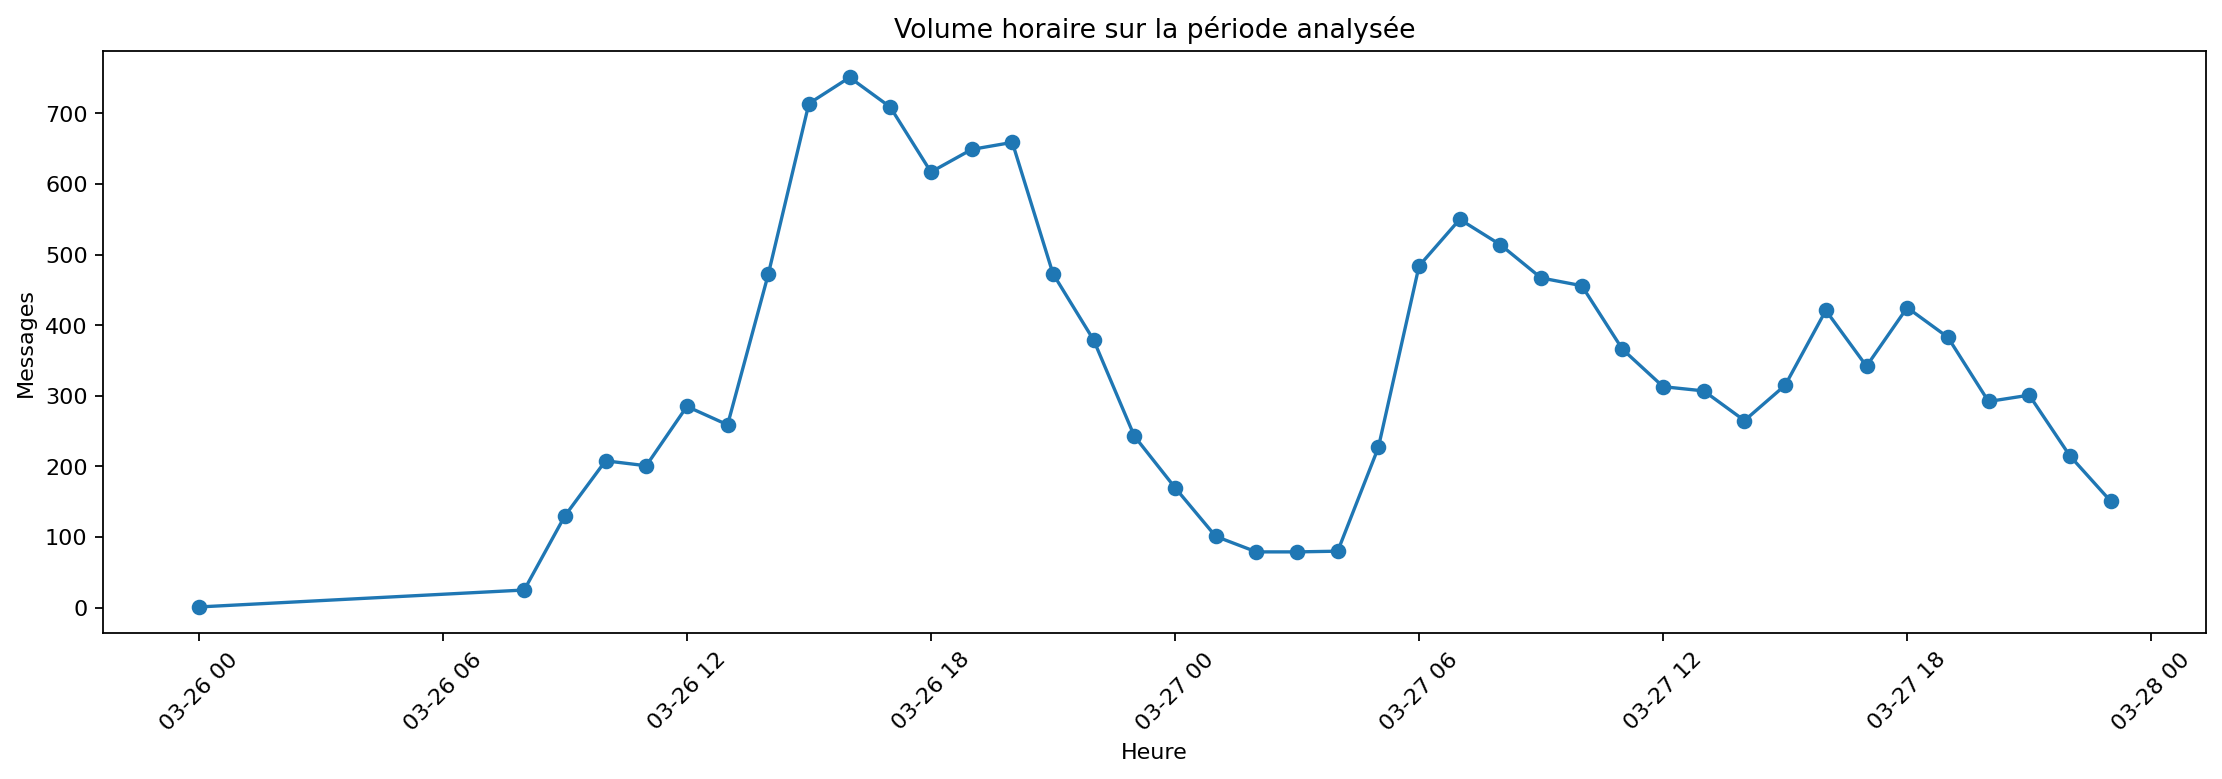

Graphique sauvegardé: /kaggle/working/agent1_outputs/figures/agent1_26_27_mars_narratifs.png


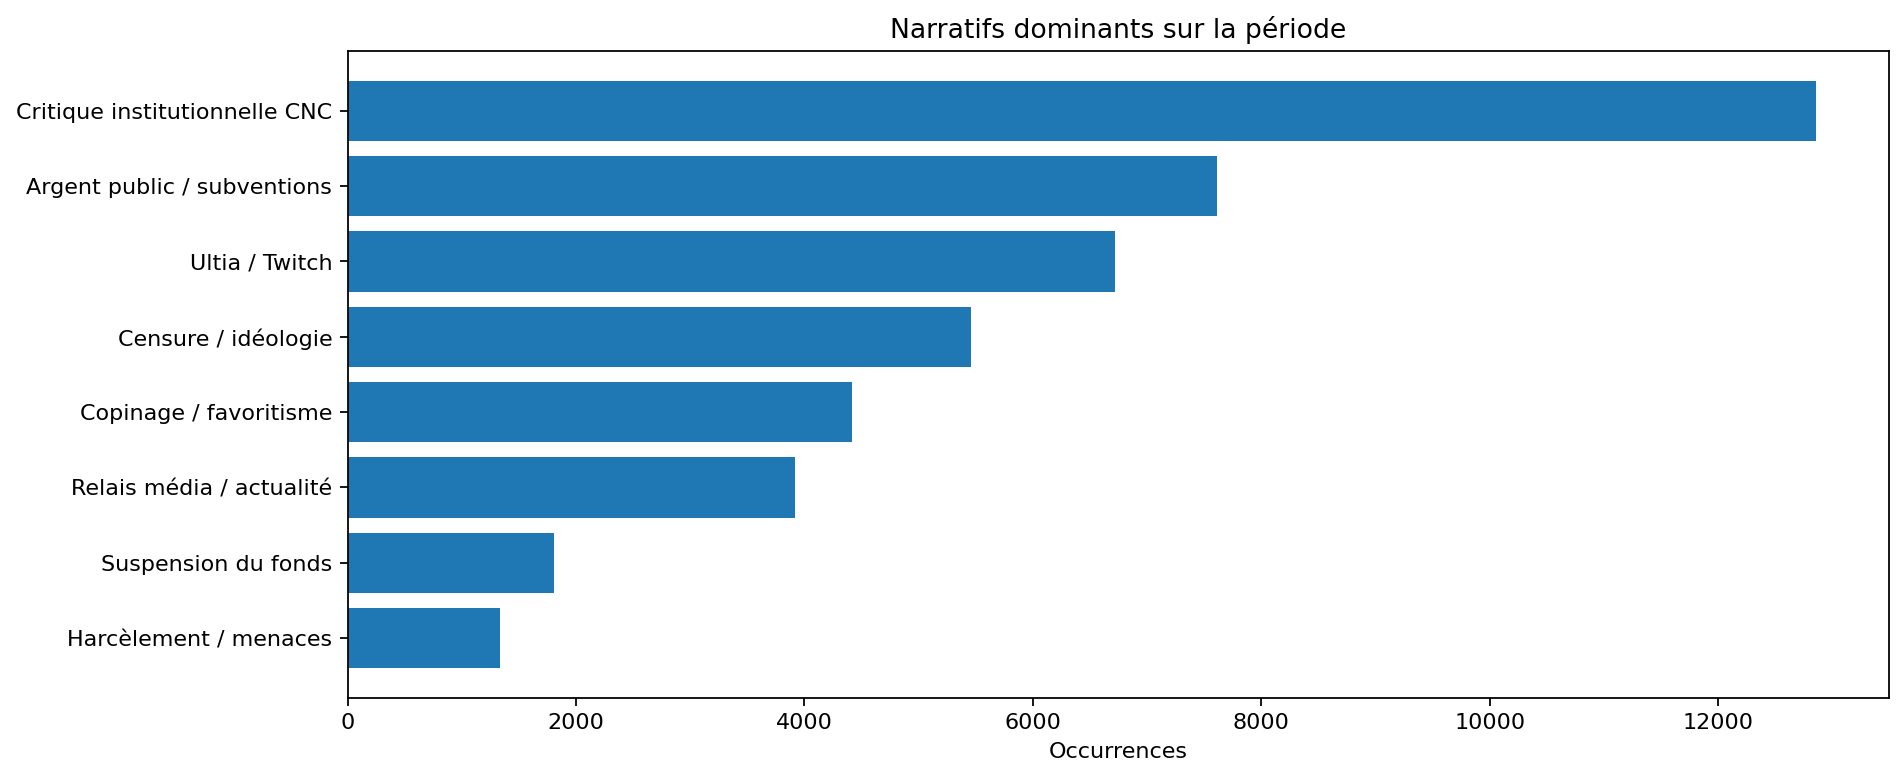

Graphique sauvegardé: /kaggle/working/agent1_outputs/figures/agent1_26_27_mars_top_auteurs.png


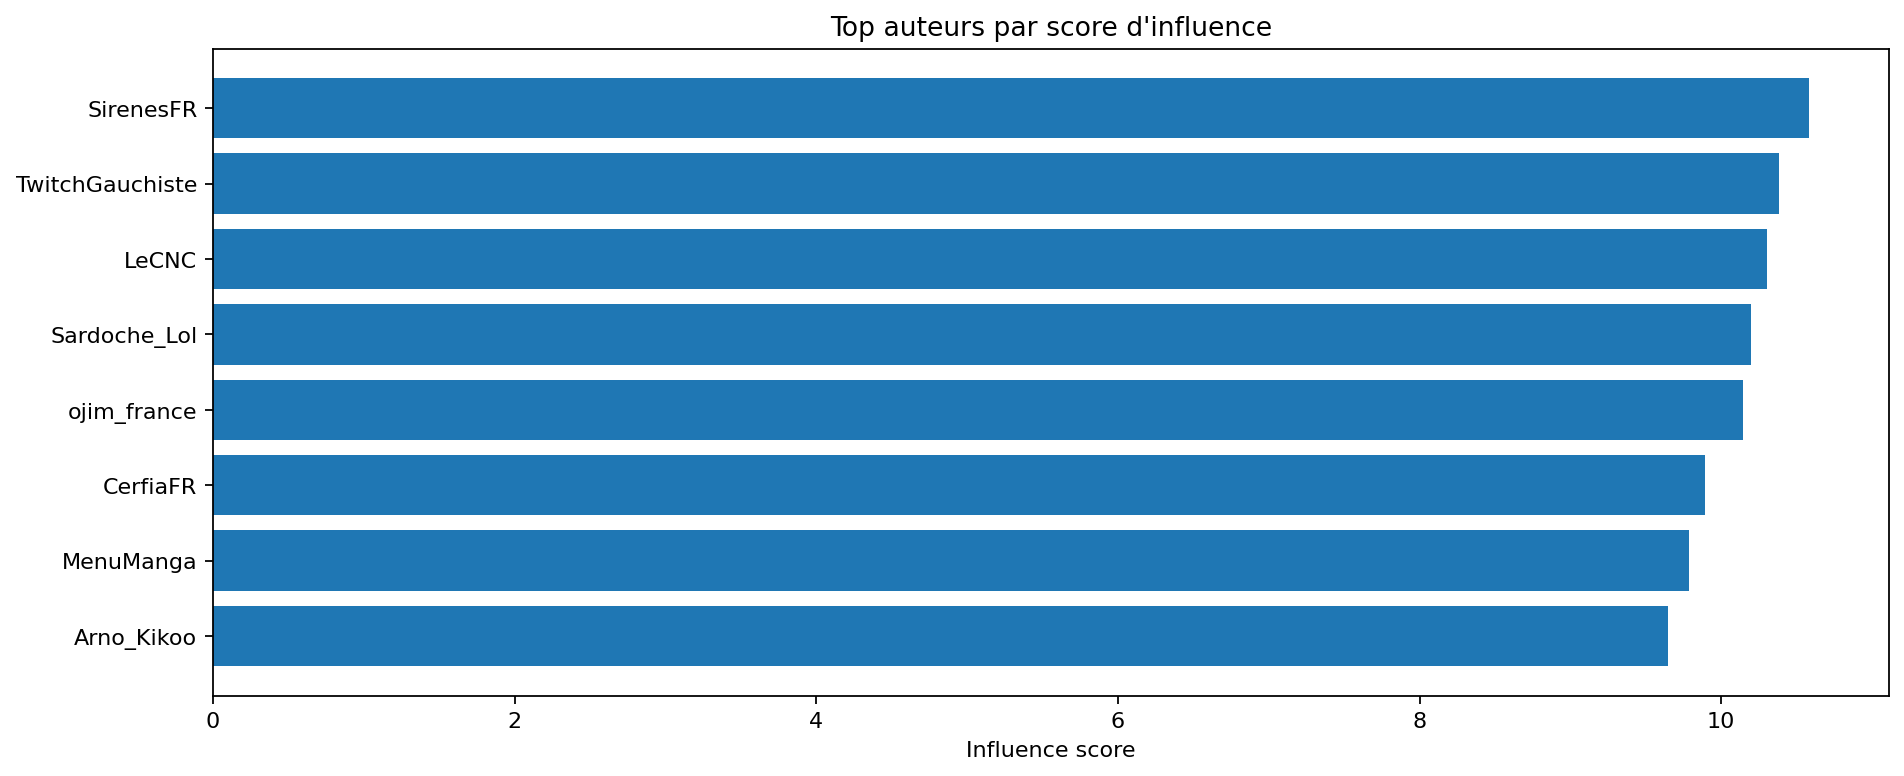

In [15]:
# ============================================================
# 14. Graphiques dédiés à une période analysée
# ============================================================

def plot_period_analysis(result, prefix="periode"):
    ht = result["hourly_timeline"]
    narr = result["narratives"].head(8)
    authors = result["top_authors"].head(8)
    
    plt.figure(figsize=(14, 5))
    plt.plot(ht["hour"], ht["messages"], marker="o")
    plt.title("Volume horaire sur la période analysée")
    plt.xlabel("Heure")
    plt.ylabel("Messages")
    plt.xticks(rotation=45)
    save_fig(f"{prefix}_volume_horaire.png")
    
    plt.figure(figsize=(12, 5))
    plt.barh(narr["narrative"][::-1], narr["count"][::-1])
    plt.title("Narratifs dominants sur la période")
    plt.xlabel("Occurrences")
    save_fig(f"{prefix}_narratifs.png")
    
    plt.figure(figsize=(12, 5))
    plt.barh(authors["author"][::-1], authors["influence_score"][::-1])
    plt.title("Top auteurs par score d'influence")
    plt.xlabel("Influence score")
    save_fig(f"{prefix}_top_auteurs.png")

plot_period_analysis(result_26_27, prefix="agent1_26_27_mars")

## 15. Option bonus : LLM local sur GPU T4×2

Cette partie transforme les chiffres de l'Agent 1 en **brief rédigé professionnellement**.

Elle est optionnelle : si Kaggle n'a pas Internet ou si le modèle ne se télécharge pas, l'agent fonctionne quand même grâce au brief déterministe.

Modèle conseillé : `Qwen/Qwen2.5-3B-Instruct`, léger et bon en français.  
Sur T4×2, `device_map="auto"` permet d'utiliser automatiquement le ou les GPU disponibles.

In [21]:
# ============================================================
# 15. LLM optionnel sur GPU : chargement robuste
# ============================================================

USE_LOCAL_LLM = True  # Mettez True si vous voulez activer le LLM local sur Kaggle GPU
MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"

llm_tokenizer = None
llm_model = None


def load_local_llm(model_id=MODEL_ID):
    global llm_tokenizer, llm_model
    if not HAS_TORCH:
        print("Torch indisponible : impossible de charger le LLM local.")
        return None, None
    
    try:
        from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
        import torch
        
        print("Chargement du tokenizer:", model_id)
        tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
        
        if torch.cuda.is_available():
            print("GPU disponible. Chargement en 4-bit avec device_map='auto'.")
            bnb_config = BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_compute_dtype=torch.float16,
                bnb_4bit_use_double_quant=True,
                bnb_4bit_quant_type="nf4",
            )
            max_memory = {i: "14GiB" for i in range(torch.cuda.device_count())}
            model = AutoModelForCausalLM.from_pretrained(
                model_id,
                quantization_config=bnb_config,
                device_map="auto",
                max_memory=max_memory,
                trust_remote_code=True,
            )
        else:
            print("Pas de GPU. Chargement CPU en float32, plus lent.")
            model = AutoModelForCausalLM.from_pretrained(model_id, trust_remote_code=True)
        
        llm_tokenizer, llm_model = tokenizer, model
        print("LLM chargé avec succès.")
        return tokenizer, model
    except Exception as e:
        print("Erreur chargement LLM:", repr(e))
        print("L'agent continue avec le brief déterministe.")
        return None, None

if USE_LOCAL_LLM:
    load_local_llm(MODEL_ID)
else:
    print("LLM local désactivé. Mettez USE_LOCAL_LLM = True pour l'activer.")

Chargement du tokenizer: Qwen/Qwen2.5-3B-Instruct


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

GPU disponible. Chargement en 4-bit avec device_map='auto'.
Erreur chargement LLM: ImportError('Using `bitsandbytes` 4-bit quantization requires bitsandbytes: `pip install -U bitsandbytes>=0.46.1`')
L'agent continue avec le brief déterministe.


In [17]:
# Petite correction si vous avez copié l'ancien nom de variable
try:
    USE_LOCAL_LM
except NameError:
    USE_LOCAL_LM = USE_LOCAL_LLM

In [18]:
# ============================================================
# 16. Génération d'un brief LLM à partir des chiffres de l'Agent 1
# ============================================================


def build_llm_context(result, max_posts=5):
    k = result["kpis"]
    narr = result["narratives"].head(8).to_dict(orient="records")
    authors = result["top_authors"].head(8).to_dict(orient="records")
    posts = result["top_posts"].head(max_posts)[["dt", "author", "engagement_type", "likes", "shares", "reach", "text_raw"]].to_dict(orient="records")
    context = {
        "periode": result["periode"],
        "kpis": k,
        "crisis_velocity_score": result["crisis_velocity_score"],
        "narratifs": narr,
        "top_auteurs": authors,
        "top_posts": posts,
    }
    return json.dumps(context, ensure_ascii=False, indent=2, default=str)


def generate_llm_brief(result, max_new_tokens=900):
    if llm_tokenizer is None or llm_model is None:
        print("LLM non chargé. Retour du brief déterministe.")
        return result["brief_deterministe"]
    
    import torch
    context = build_llm_context(result)
    messages = [
        {
            "role": "system",
            "content": (
                "Tu es un analyste senior en communication de crise et analyse de réseaux sociaux. "
                "Tu dois rester neutre, factuel, prudent, sans jugement politique. "
                "Tu analyses une dynamique virale, pas une fake news. "
                "Tu n'inventes aucun chiffre : tu utilises uniquement le contexte JSON fourni."
            ),
        },
        {
            "role": "user",
            "content": (
                "Voici les chiffres calculés par l'Agent Analyste. "
                "Rédige un brief professionnel en français pour une cellule de crise CNC. "
                "Structure : 1) diagnostic, 2) narratifs, 3) acteurs, 4) propagation, 5) risques, 6) recommandations immédiates.\n\n"
                f"CONTEXTE_JSON:\n{context}"
            ),
        },
    ]
    
    prompt = llm_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = llm_tokenizer(prompt, return_tensors="pt")
    device = next(llm_model.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        output_ids = llm_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=0.2,
            repetition_penalty=1.05,
            pad_token_id=llm_tokenizer.eos_token_id,
        )
    
    generated = output_ids[0][inputs["input_ids"].shape[-1]:]
    text = llm_tokenizer.decode(generated, skip_special_tokens=True)
    return text.strip()

# Exemple d'utilisation après chargement du LLM :
# llm_brief = generate_llm_brief(result_26_27)
# print(llm_brief)

In [19]:
# ============================================================
# 17. Fonction finale de démo pour la soutenance Jour 2
# ============================================================


def demo_agent1(start="2026-03-26 00:00:00", end="2026-03-27 23:59:59", use_llm=False):
    '''
    Fonction simple à lancer devant l'animateur/jury.
    Elle produit le diagnostic complet d'une période.
    '''
    result = agent1.analyze_period(start=start, end=end, top_n=10)
    
    if use_llm and llm_tokenizer is not None and llm_model is not None:
        brief = generate_llm_brief(result)
    else:
        brief = result["brief_deterministe"]
    
    from IPython.display import Markdown, display
    display(Markdown(brief))
    
    print("\n--- Top narratifs ---")
    display(result["narratives"].head(8))
    
    print("\n--- Top auteurs ---")
    display(result["top_authors"].head(8))
    
    print("\n--- Top posts ---")
    display(result["top_posts"].head(5))
    
    return result

# Démo recommandée pour Jour 2
final_demo_result = demo_agent1("2026-03-26 00:00:00", "2026-03-27 23:59:59", use_llm=False)

## Brief Agent 1 — Analyste de crise

**Période analysée :** 2026-03-26 00:16:32 → 2026-03-27 23:59:48
**Niveau estimé :** CRISE ÉLEVÉE
**Crisis Velocity Score :** 71.8/100

### 1. Chiffres clés
- 14 078 messages publiés par 4 792 auteurs uniques.
- 85.2% de retweets/reposts : la crise fonctionne surtout par amplification.
- Reach cumulé estimé : 36 782 107 ; impressions : 37 704 952.
- Sentiment négatif : 31.3% ; risque moyen : 3.12/5.

### 2. Narratif dominant
- Narratif principal détecté : **Critique institutionnelle CNC**.
- Critique institutionnelle CNC : 12 853 occurrences (91.3% des messages).
- Argent public / subventions : 7 610 occurrences (54.1% des messages).
- Ultia / Twitch : 6 715 occurrences (47.7% des messages).
- Censure / idéologie : 5 461 occurrences (38.8% des messages).
- Copinage / favoritisme : 4 412 occurrences (31.3% des messages).

### 3. Acteurs et amplification
- Compte le plus influent sur la période : **@SirenesFR** selon le score d'influence calculé.
- @SirenesFR : 7 messages, reach 2 593 256, shares 3 388.
- @TwitchGauchiste : 4 messages, reach 4 073 896, shares 2 104.
- @LeCNC : 2 messages, reach 2 909 506, shares 1 737.
- @Sardoche_Lol : 11 messages, reach 1 120 345, shares 1 369.
- @ojim_france : 6 messages, reach 1 459 006, shares 3 743.

### 4. Lecture stratégique
- Le sujet doit être traité comme une **dynamique virale**, pas comme une simple vérification de fake news.
- Le point à surveiller est la mutation du débat : personne impliquée → institution → argent public / légitimité du fonds.
- La cellule de crise doit répondre sur les règles, la transparence et les faits, sans entrer dans un affrontement politique.


--- Top narratifs ---


,narrative,count,pct_messages
0,Critique institutionnelle CNC,12853,91.298480
1,Argent public / subventions,7610,54.055974
2,Ultia / Twitch,6715,47.698537
3,Censure / idéologie,5461,38.791021
4,Copinage / favoritisme,4412,31.339679
5,Relais média / actualité,3917,27.823554
6,Suspension du fonds,1809,12.849837
7,Harcèlement / menaces,1331,9.454468



--- Top auteurs ---


,author,messages,retweets,likes,shares,reach,impressions,followers,risk_mean,influence_score
2610,SirenesFR,7,0,23837,3388,2593256,7384408,105790,4.142857,10.581695
2859,TwitchGauchiste,4,0,17057,2104,4073896,11243267,31654,3.750000,10.386140
1601,LeCNC,2,0,19504,1737,2909506,5172617,90748,3.500000,10.301477
2557,Sardoche_Lol,11,5,15778,1369,1120345,826508,610751,3.818182,10.194866
4257,ojim_france,6,2,11684,3743,1459006,717598,35850,3.833333,10.141137
547,CerfiaFR,1,0,11829,967,967287,1389301,1285098,5.000000,9.894224
1911,MenuManga,6,0,16229,1127,716732,922235,129261,3.000000,9.786385
245,Arno_Kikoo,30,1,7972,957,1312224,1623449,5322,2.900000,9.644885



--- Top posts ---


,dt,author,engagement_type,sentiment,likes,comments,shares,reach,risk_level,text_raw
34057,2026-03-26 14:08:46,LeCNC,ORIGINAL,neutral,19503,1768,1735,2855797,5,"Le CNC a pris connaissance des déclarations publiques de la streameuse Ultia, nouvellement nommée membre de la commission du fonds d’aide à la création pour les plateformes sociales (sans y avoir encore siégé), relat..."
35185,2026-03-26 08:54:56,Sardoche_Lol,QUOTE,neutral,13505,276,1330,691254,5,Résumons :\n\nÀ partir du centre-droit\n- Cancel \n- Zero sponsor\n- Se font refuser tous les financements verrouillés par la gauche\n\nÀ gauche \n- Camp du bien\n- Sponsors\n- Se financent entre potes via le CNC\n\n...
33674,2026-03-26 14:55:43,CerfiaFR,ORIGINAL,neutral,11829,516,967,967287,5,"🇫🇷🎙️ FLASH | « Si t’es d’extrême droite, désolé, pas de thune. Si t’es mon pote, je te sauce le projet. » Après ces propos, dans lesquels elle reconnaît sa partialité, le CNC annonce avoir mis fin aux fonctions de la..."
28596,2026-03-26 23:19:21,libremax_off,ORIGINAL,negative,10132,81,1209,366236,4,"Le plus fou c'est pas qu'Ultia ait révélé que l'argent du CNC est distribué par copinage et gauchisme, ça on le savait déjà.\n\nLe plus fou c'est qu'elle l'ai dit comme si c'était normal. Que notre argent leur appart..."
35161,2026-03-26 09:17:29,MenuManga,QUOTE,negative,10199,114,827,349974,3,Coupez moi cette merde de CNC talent et rendez l'argent.


In [20]:
# ============================================================
# 18. Export final : fichiers pour les slides Jour 2 / Jour 3
# ============================================================

# Exports globaux utiles
compute_kpis(df)

daily_timeline.to_csv(OUTDIR / "timeline_journaliere.csv", index=False, encoding="utf-8-sig")
hourly_timeline.to_csv(OUTDIR / "timeline_horaire.csv", index=False, encoding="utf-8-sig")
peaks_daily.to_csv(OUTDIR / "pics_journaliers_detectes.csv", index=False, encoding="utf-8-sig")
peaks_hourly.to_csv(OUTDIR / "pics_horaires_detectes.csv", index=False, encoding="utf-8-sig")
narratives_global.to_csv(OUTDIR / "narratifs_globaux.csv", index=False, encoding="utf-8-sig")
top_authors(df, n=50).to_csv(OUTDIR / "top_50_auteurs_influence.csv", index=False, encoding="utf-8-sig")
top_hashtags(df, n=50).to_csv(OUTDIR / "top_50_hashtags.csv", index=False, encoding="utf-8-sig")

# Corpus enrichi léger pour Agent 2
cols_export = [
    "dt", "author", "engagement_type", "sentiment", "likes", "comments", "shares", "reach",
    "impressions", "is_retweet", "is_reply", "is_quote", "is_original", "main_narrative", "narratives", "risk_level", "text_raw", "text_norm"
]
existing_cols_export = [c for c in cols_export if c in df.columns]
df[existing_cols_export].to_csv(OUTDIR / "corpus_enrichi_agent1.csv", index=False, encoding="utf-8-sig")

print("Tous les exports sont disponibles ici:")
print(OUTDIR)
print("\nFichiers principaux:")
for p in sorted(OUTDIR.glob("*")):
    if p.is_file():
        print("-", p.name)

Tous les exports sont disponibles ici:
/kaggle/working/agent1_outputs

Fichiers principaux:
- agent1_26_27_mars_hourly_timeline.csv
- agent1_26_27_mars_narratives.csv
- agent1_26_27_mars_rapport.md
- agent1_26_27_mars_top_authors.csv
- agent1_26_27_mars_top_hashtags.csv
- agent1_26_27_mars_top_posts.csv
- agent1_pic_principal_hourly_timeline.csv
- agent1_pic_principal_narratives.csv
- agent1_pic_principal_rapport.md
- agent1_pic_principal_top_authors.csv
- agent1_pic_principal_top_hashtags.csv
- agent1_pic_principal_top_posts.csv
- corpus_enrichi_agent1.csv
- narratifs_globaux.csv
- pics_horaires_detectes.csv
- pics_journaliers_detectes.csv
- timeline_horaire.csv
- timeline_journaliere.csv
- top_50_auteurs_influence.csv
- top_50_hashtags.csv


# Résultat attendu pour le Jour 2

À la fin de ce notebook, vous avez un **Agent Analyste de crise** capable de :

1. charger et nettoyer le corpus ;
2. détecter les pics de crise ;
3. analyser une période choisie ;
4. sortir les chiffres clés ;
5. identifier les narratifs dominants ;
6. repérer les comptes moteurs ;
7. produire un brief clair pour la cellule de crise ;
8. exporter les graphes et CSV nécessaires aux slides.

## Phrase à dire à l'animateur

> “Nous avons construit l’Agent Analyste. Il transforme le corpus brut en diagnostic de crise : volume, vitesse, acteurs, narratifs, risque et brief opérationnel. Demain, cet agent nourrira l’Agent Stratège et l’Agent Rédacteur dans une orchestration complète.”

## Prochaine étape

Construire l’**Agent 2 — Classificateur de narratifs**, plus fin que les règles rapides utilisées ici :

- classification multi-label ;
- score de toxicité/risque ;
- évolution des narratifs dans le temps ;
- comparaison avant/après le pic.